In [1]:
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import numpy as np

import evoscape.landscape_visuals as vis
import evoscape.morphogen_regimes as mr

from evoscape.modules import *
from evoscape.landscapes import Landscape, Somitogenesis_Landscape

In [2]:
order_colors = (
    'tab:green',
    # 'lightblue',
    'tab:blue',
    'tab:purple',
    'lightgreen',
)

In [91]:
%autoreload
def add_phase_plots(
    land,
    xx,
    yy,
    t,
    basin_dt=0.05,
    basin_steps=800,
    fp_tol=5e-2,
    vel_tol=2e-3,
    cycle_window=256,
):
    phase_result = land.find_phase_objects_manifold(
        t,
        xx,
        yy,
        dt=basin_dt,
        n_steps=basin_steps,
        fp_tol=fp_tol,
        vel_tol=vel_tol,
        cycle_window=cycle_window,
    )

    basin_grid = land.find_attractor_basins_manifold(phase_result=phase_result)

    _, basin_ax, _ = vis.plot_attractor_basins_t(
        land,
        xx,
        yy,
        t,
        phase_result=phase_result,
        basin_grid=basin_grid,
        show_saddle_manifolds=True,
        nullclines=False,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    _, skeleton_ax, _ = vis.plot_phase_skeleton_t(
        land,
        xx,
        yy,
        t,
        phase_result=phase_result,
        show_saddle_manifolds=True,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    return phase_result, basin_grid


In [20]:
def add_phase_plots(
    land,
    xx,
    yy,
    t,
    n_grid=25,
    manifold_step_size=0.025,
    manifold_steps=800,
    basin_dt=0.04,
    basin_steps=800,
    fp_tol=2e-2,
    vel_tol=2e-3,
    cycle_window=256,
):
    x_range = (float(np.min(xx)), float(np.max(xx)))
    y_range = (float(np.min(yy)), float(np.max(yy)))

    fixed_points = land.find_fixed_points(t, x_range, y_range, n_grid=n_grid)

    saddle_manifolds = land.find_saddle_manifolds(
        t,
        fixed_points=fixed_points,
        x_range=x_range,
        y_range=y_range,
        step_size=manifold_step_size,
        n_steps=manifold_steps,
        termination_tol=fp_tol,
        velocity_tol=vel_tol,
    )

    phase_result = land.find_phase_objects_manifold(
        t,
        xx,
        yy,
        fixed_points=fixed_points,
        saddle_manifolds=saddle_manifolds,
        dt=basin_dt,
        n_steps=basin_steps,
        fp_tol=fp_tol,
        vel_tol=vel_tol,
        cycle_window=cycle_window,
    )

    basin_grid = land.find_attractor_basins_manifold(phase_result=phase_result)

    _, basin_ax, _ = vis.plot_attractor_basins_t(
        land,
        xx,
        yy,
        t,
        phase_result=phase_result,
        basin_grid=basin_grid,
        show_saddle_manifolds=True,
        nullclines=False,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    _, skeleton_ax, _ = vis.plot_phase_skeleton_t(
        land,
        xx,
        yy,
        t,
        phase_result=phase_result,
        show_saddle_manifolds=True,
        basin_coloring='module',
        module_order_colors=order_colors,
    )

    return phase_result, basin_grid


In [3]:
# %autoreload
# def add_phase_plots(
#     land,
#     xx,
#     yy,
#     t,
#     n_grid=25,
#     manifold_step_size=0.025,
#     manifold_steps=800,
#     basin_dt=0.04,
#     basin_steps=800,
#     fp_tol=2e-2,
#     vel_tol=2e-3,
#     cycle_window=256,
# ):
#     x_range = (float(np.min(xx)), float(np.max(xx)))
#     y_range = (float(np.min(yy)), float(np.max(yy)))
#     fixed_points = land.find_fixed_points(t, x_range, y_range, n_grid=n_grid)
#     saddle_manifolds = land.find_saddle_manifolds(
#         t,
#         fixed_points=fixed_points,
#         x_range=x_range,
#         y_range=y_range,
#         step_size=manifold_step_size,
#         n_steps=manifold_steps,
#         termination_tol=fp_tol,
#         velocity_tol=vel_tol,
#     )
#     basin_result = land.find_attractor_basins_manifold(
#         t,
#         xx,
#         yy,
#         fixed_points=fixed_points,
#         saddle_manifolds=saddle_manifolds,
#         dt=basin_dt,
#         n_steps=basin_steps,
#         fp_tol=fp_tol,
#         vel_tol=vel_tol,
#         cycle_window=cycle_window,
#     )
#     _, basin_ax, _ = vis.plot_attractor_basins_t(
#         land,
#         xx,
#         yy,
#         t,
#         basin_result=basin_result,
#         fixed_points=fixed_points,
#         saddle_manifolds=saddle_manifolds,
#         show_saddle_manifolds=True,
#         nullclines=False,
#         basin_coloring='module',
#         module_order_colors=order_colors,
#     )
#
#     _, skeleton_ax, _ = vis.plot_phase_skeleton_t(
#         land,
#         xx,
#         yy,
#         t,
#         basin_result=basin_result,
#         fixed_points=fixed_points,
#         saddle_manifolds=saddle_manifolds,
#         show_saddle_manifolds=True,
#         basin_coloring='module',
#         module_order_colors=order_colors,
#     )
#     return basin_result
#


In [92]:
theta1 = (0., 0.)
theta2 = (0.5, -0.5)
sig = 0.5

def thetas(t, t0, tau):
    t = np.asarray(t)
    tanh = np.tanh((t[..., None] - t0) / 2. / tau)
    theta1_t = theta1[0] + (theta1[1] - theta1[0]) / 2. * (1 + tanh)
    theta2_t = theta2[0] + (theta2[1] - theta2[0]) / 2. * (1 + tanh)
    return theta1_t, theta2_t


def two_controls(t, a, s, t0, tau, **kwargs):
    t = np.asarray(t)
    theta1_t, theta2_t = thetas(t, t0, tau)
    s_t = s[0] * np.exp( s[1] * theta1_t/2 + s[2] * theta2_t/2 )
    a_t = a * np.ones_like(s_t)

    return s_t, a_t


In [32]:
two_controls(1., (2., 3), (1., 1), (0.,1), 5.)


(array([3., 3.]), array([2., 2.]))

In [93]:
L = 2
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

x_fate = 1.0 #1.1, 1.5
y_cycle = 0.5 # 0.5
tau = 2

M1 = Node(x=-0.0, y=y_cycle, a=4., s=(0.5, 0, 1), tau=tau)
M2 = Node(x=-x_fate, y=-1., a=4.5, s=(0.5, -1, -1), tau=tau)
M3 = Node(x=+x_fate, y=-1., a=4.5, s=(0.5, +1, -1), tau=tau)
R = UnstableNode(x=0.0, y=y_cycle, a=6., s=(0.8*0.5, 0, 1), tau=tau)
C= Center(x=0, y=y_cycle, a=4., s=(0.85*0.5, 0, 1), tau=tau)
modules = [M1, M2, M3, R, C]
land = Somitogenesis_Landscape(modules, A0=0.05, x0=(0., -0.8), regime=two_controls, n_regimes=3)

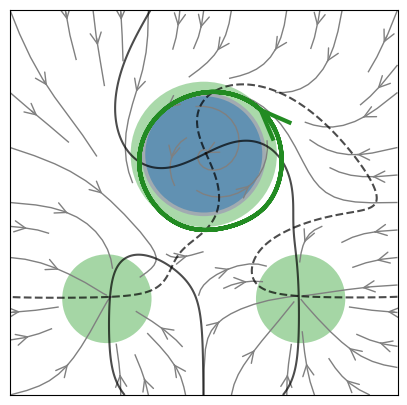

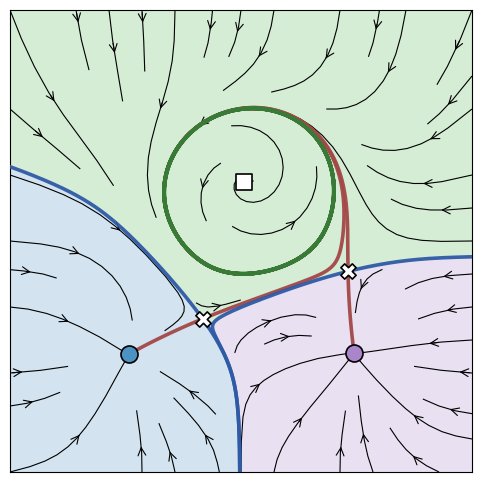

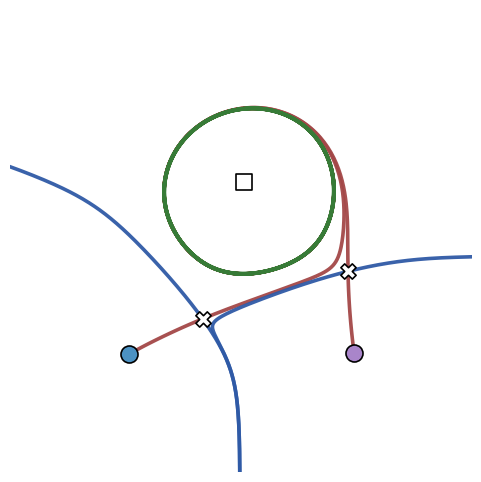

In [94]:

t = -10.
fig = vis.visualize_landscape_t(land, xx, yy, t=t, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), traj_start=100, circle_opacity=0.2)
res, grid = add_phase_plots(land, xx, yy, t=t)

In [84]:
res

{'attractors': [{'id': 0,
   'type': 'fixed_point',
   'point': array([-0.96755399, -0.98037753]),
   'fixed_point_index': 0,
   'eigenvalues': array([-4.6362919 +0.j, -4.08195246+0.j]),
   'node_id': 1},
  {'id': 1,
   'type': 'fixed_point',
   'point': array([ 0.98029437, -0.97172469]),
   'fixed_point_index': 4,
   'eigenvalues': array([-4.69129709+0.j, -4.04478778+0.j]),
   'node_id': 2},
  {'id': 2,
   'type': 'cycle',
   'center': array([0.14655113, 0.41545951]),
   'radius_mean': 0.7231393715241959,
   'radius_span': 0.15614210332834821,
   'period_steps': 161,
   'period': 16.1,
   'recurrence_distance': 0.012258054876164354,
   'trajectory': array([[ 0.31510715,  1.11771582],
          [ 0.20560498,  1.14164047],
          [ 0.08646361,  1.14883641],
          [-0.04021954,  1.13624148],
          [-0.17063637,  1.10083446],
          [-0.29896141,  1.04052222],
          [-0.41771731,  0.95524742],
          [-0.51901681,  0.84775418],
          [-0.59627121,  0.72341828],
  

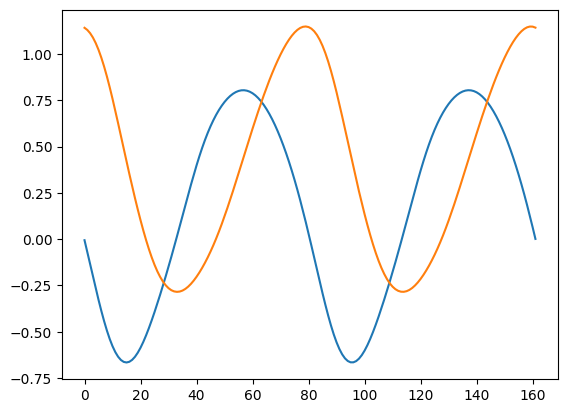

In [95]:
period_steps = res['attractors'][2]['period_steps']
# period_steps = 40
cycle = res['attractors'][2]['trajectory'][:period_steps+1]

# plt.plot(cycle[:,0], cycle[:,1])
plt.plot(cycle[:,0])
plt.plot(cycle[:,1])



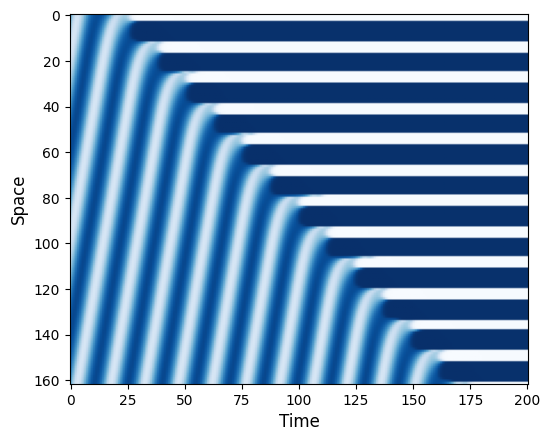

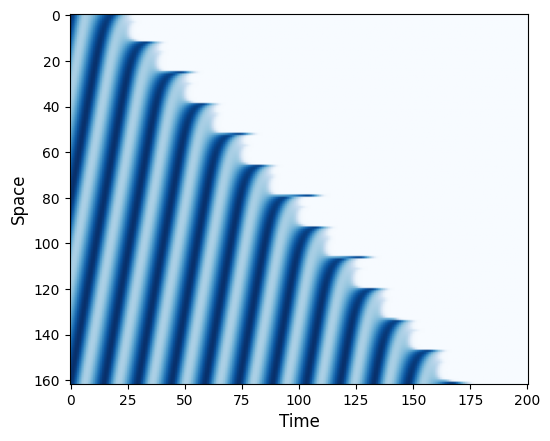

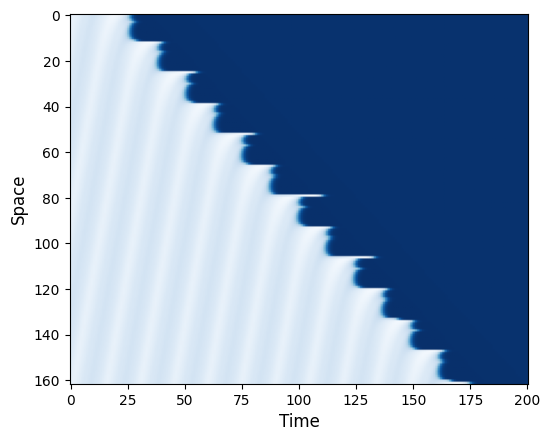

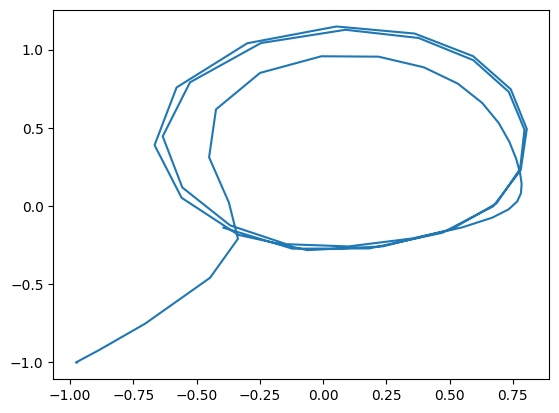

In [97]:

time_pars = (-5., 50., 201)
morphogen_times = (0.,)

fitness_pars = {
    'ncells': len(cycle),
    'time_pars': time_pars,
    'init_state': cycle.T,
    't0_shift': 0.25,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.,
    't_stable': 1, # how many timepoints should be at steady state
    'ndt': 50,
    'states': 'basin_static',
    't_freeze': -10.,
    # 'n_boundaries': 10,
}
land.get_fitness(fitness_pars)

aspect = 1
plt.imshow(land.result[0], cmap='Blues', aspect=aspect)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.imshow(land.result[1], cmap='Blues', aspect=aspect)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()


plt.imshow(land.result[0]**2+(land.result[1]-y_cycle)**2, cmap='Blues', aspect=aspect)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.plot(land.result[0][25, :], land.result[1][25, :])

# Homoclinic with left saddle

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

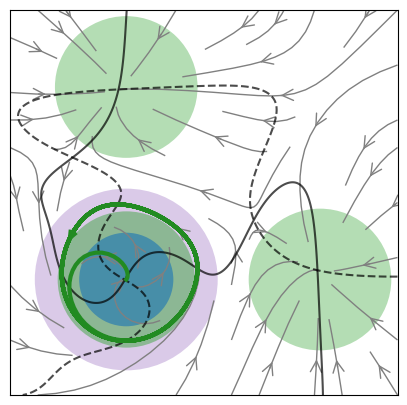

In [98]:
%autoreload

L = 10.
npoints = 401
q = np.linspace(-L*0.6, L*1.4, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

M1 = Node(x=0., y=0., a=5., s=3)
M2 = Node(x=0., y=10., a=(3,4), s=(3,4), tau=5) # 3, 3
M3 = Node(x=10., y=0., a=(3,4), s=(3,4), tau=5)
# M4 = Node(x=8, y=8, a=0.5, s=5)
M4 = Node(x=5, y=6, a=0.5, s=3)

C1 = Center(x=0, y=0, a=3, s=4)
R1 = UnstableNode(x=0, y=0, a=(10, 10), s=(2., 2.5), tau=5)

land = Somitogenesis_Landscape([C1, M1, M2, M3, R1], regime=mr.mr_sigmoid, n_regimes=2, A0 = 0.001, x0 = (5, 5))

# _____________________________________________________
fig = vis.visualize_landscape_t(land, xx, yy, t=-10., traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
res, grid = add_phase_plots(land, xx, yy, t=-10.)

In [38]:
res.keys()

dict_keys(['attractors', 'fixed_points', 'saddle_manifolds', 'objects', 'boundary_mask', 'region_ids', 'region_attractor_ids', 'x_coords', 'y_coords', 'xx_shape', 'method'])

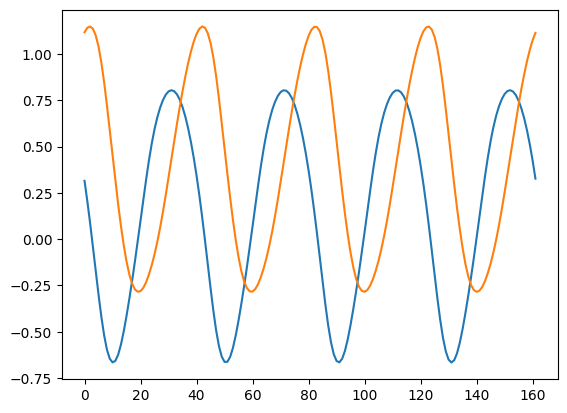

In [77]:
period_steps = res['attractors'][2]['period_steps']

cycle = res['attractors'][2]['trajectory'][:period_steps+1]

plt.plot(cycle[:,0])
plt.plot(cycle[:,1])

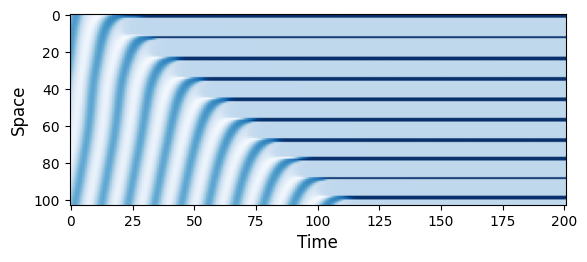

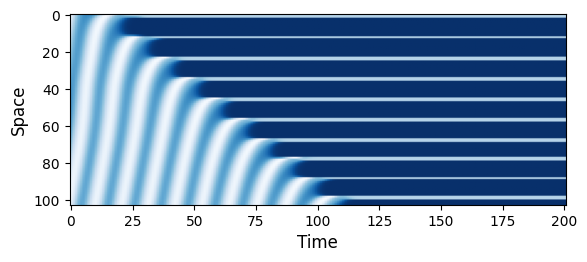

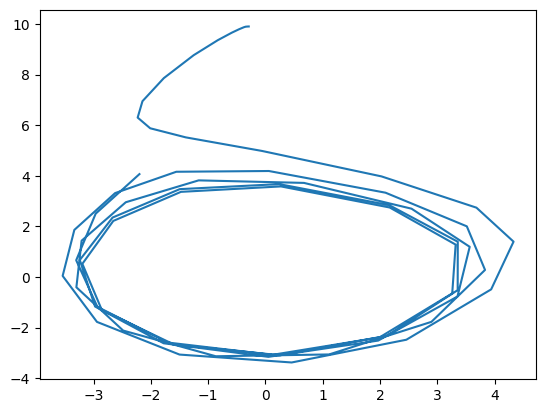

In [39]:

time_pars = (-5., 50., 201)
morphogen_times = (0.,)

fitness_pars = {
    'ncells': len(cycle),
    'time_pars': time_pars,
    'init_state': cycle.T,
    't0_shift': 0.25,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.0,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.,
    't_stable': 1, # how many timepoints should be at steady state
    'ndt': 50,
    'states': 'basin_static',
    't_freeze': -10.,
    # 'n_boundaries': 10,
}
land.get_fitness(fitness_pars)

plt.imshow(land.result[0], cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.imshow(land.result[1], cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.plot(land.result[0][55, :], land.result[1][55, :])

In [13]:
res

{'labels': array([[2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'attractors': [{'id': 0,
   'type': 'fixed_point',
   'point': array([-0.39903388,  9.87396471]),
   'fixed_point_index': 1,
   'stability': 'attractor',
   'eigenvalues': array([-3.39972425+0.j, -2.69155502+0.j])},
  {'id': 1,
   'type': 'fixed_point',
   'point': array([9.8693408 , 0.48195108]),
   'fixed_point_index': 4,
   'stability': 'attractor',
   'eigenvalues': array([-2.65498187+0.j, -3.36107079+0.j])},
  {'id': 2,
   'type': 'cycle',
   'center': array([-0.23457807,  0.30028297]),
   'radius_mean': 3.485952104739482,
   'radius_span': 0.8399355948906733,
   'period_steps': 157,
   'period': 6.28,
   'recurrence_distance': 0.033337711218017006,
   'trajectory': array([[ 2.29346142,  2.91918254],
          [ 2.0382231 ,  3.09200945],
          [ 1.76762703,

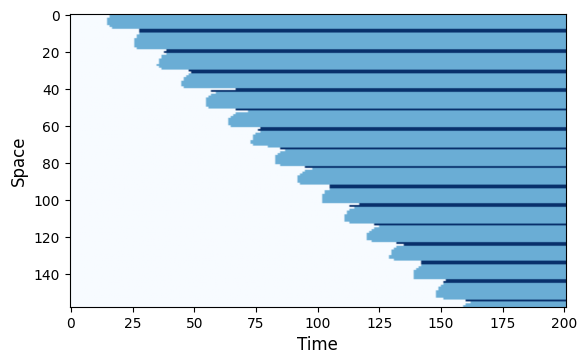

In [8]:
states = land.get_cell_states(0., coordinate=(land.result[0].flatten(), land.result[1].flatten()), measure='basin static', t_freeze=-10.)
states=np.reshape(states, land.result[0].shape)

plt.imshow(states, cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

## Phase space plots

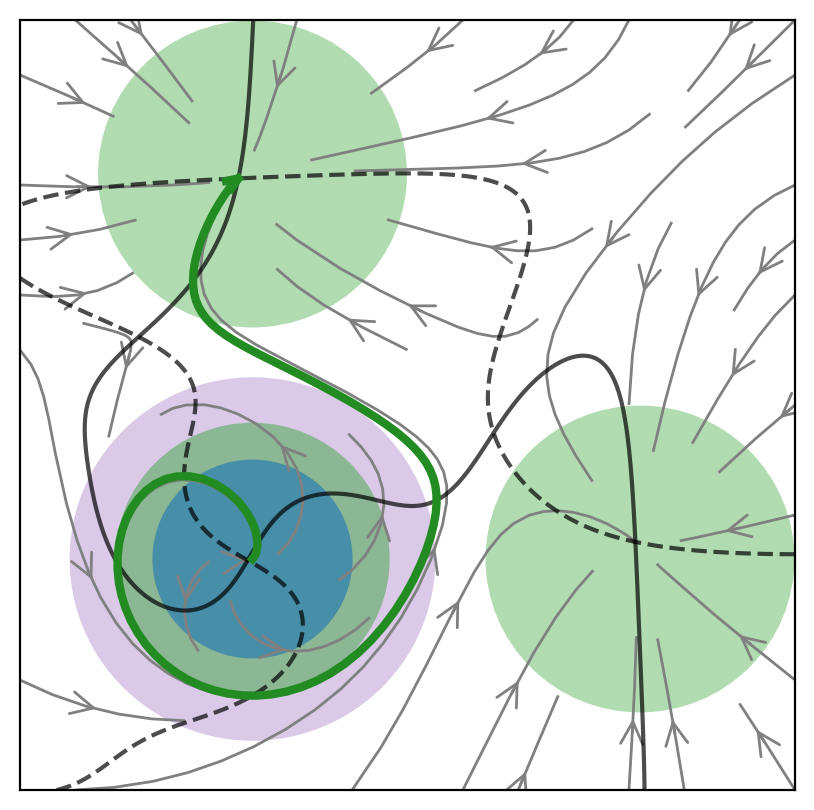

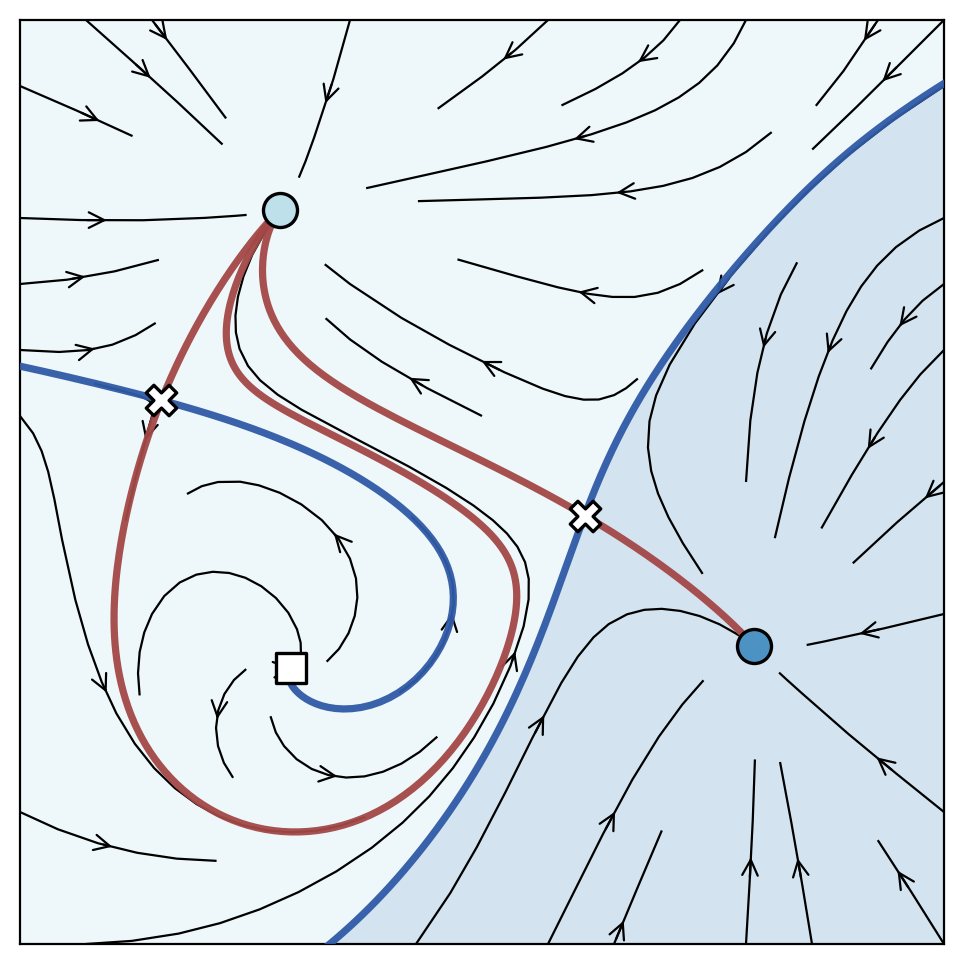

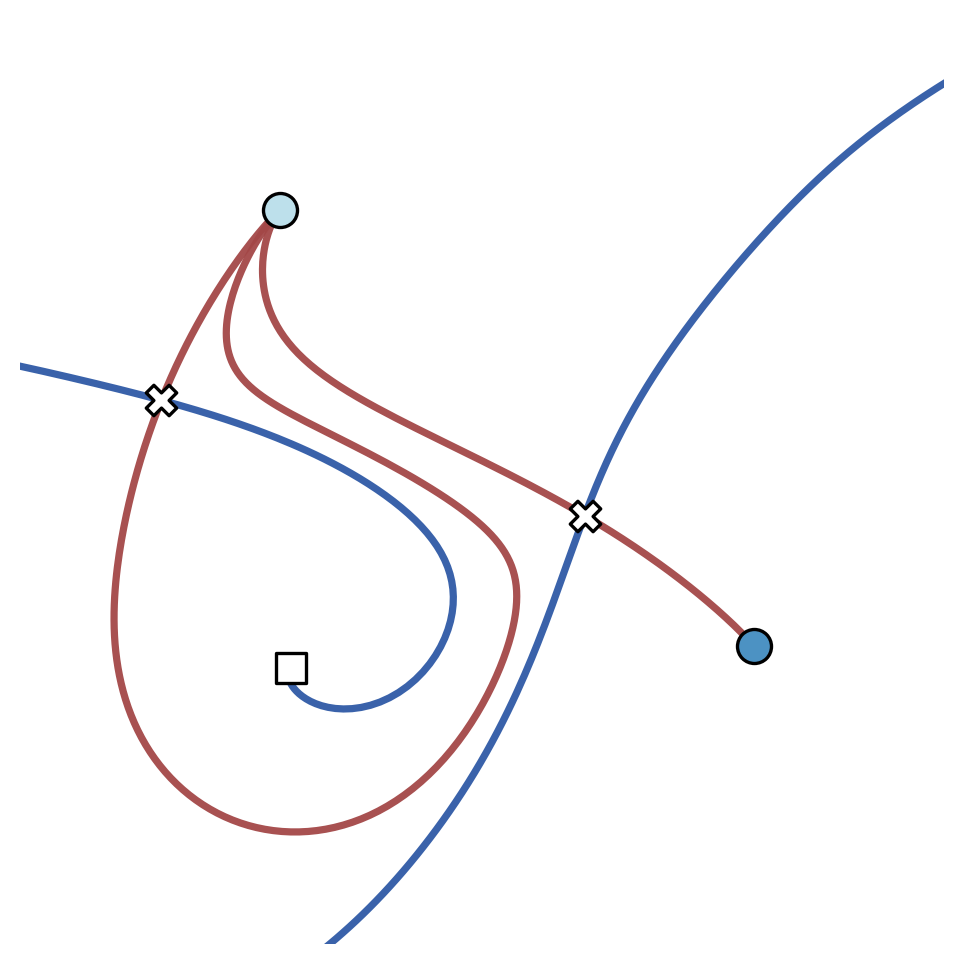

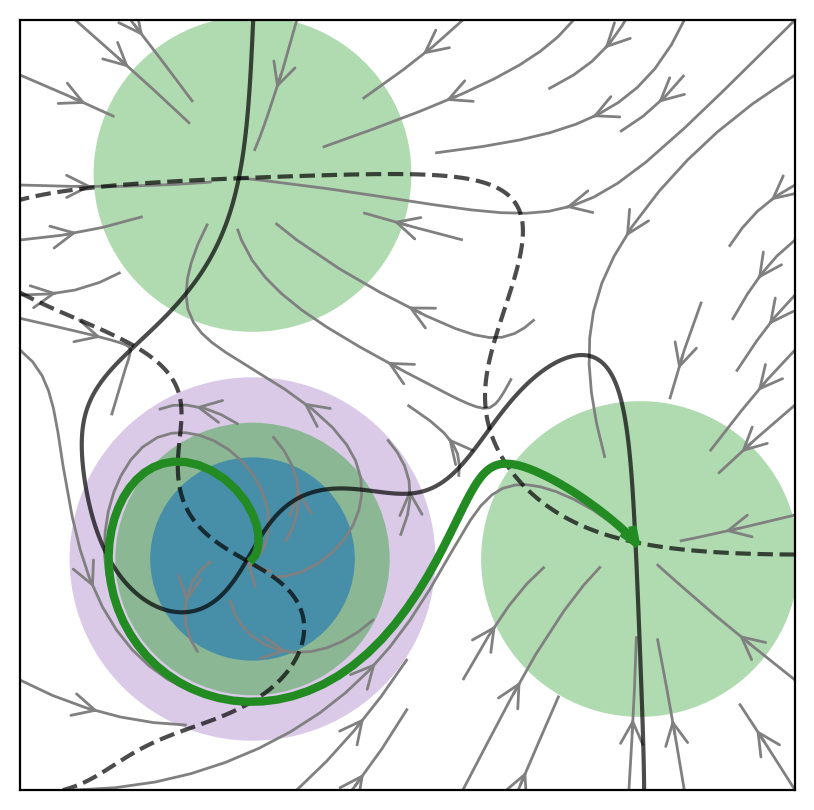

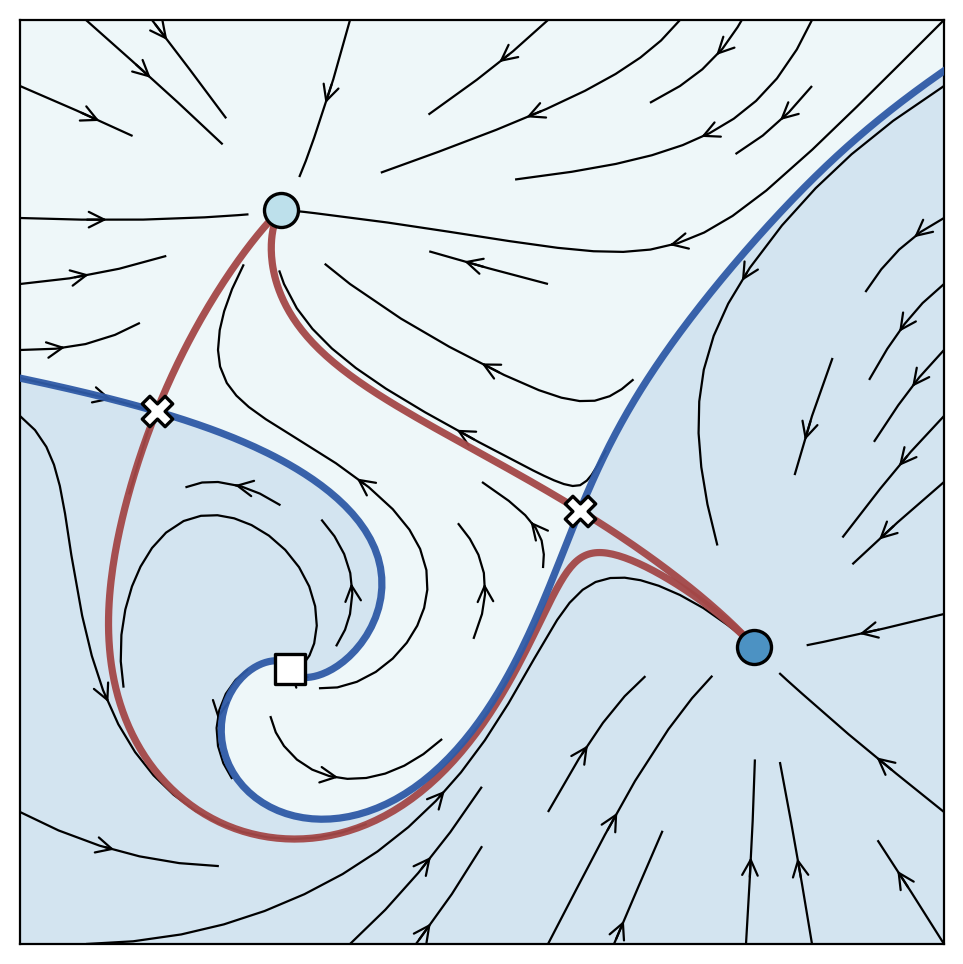

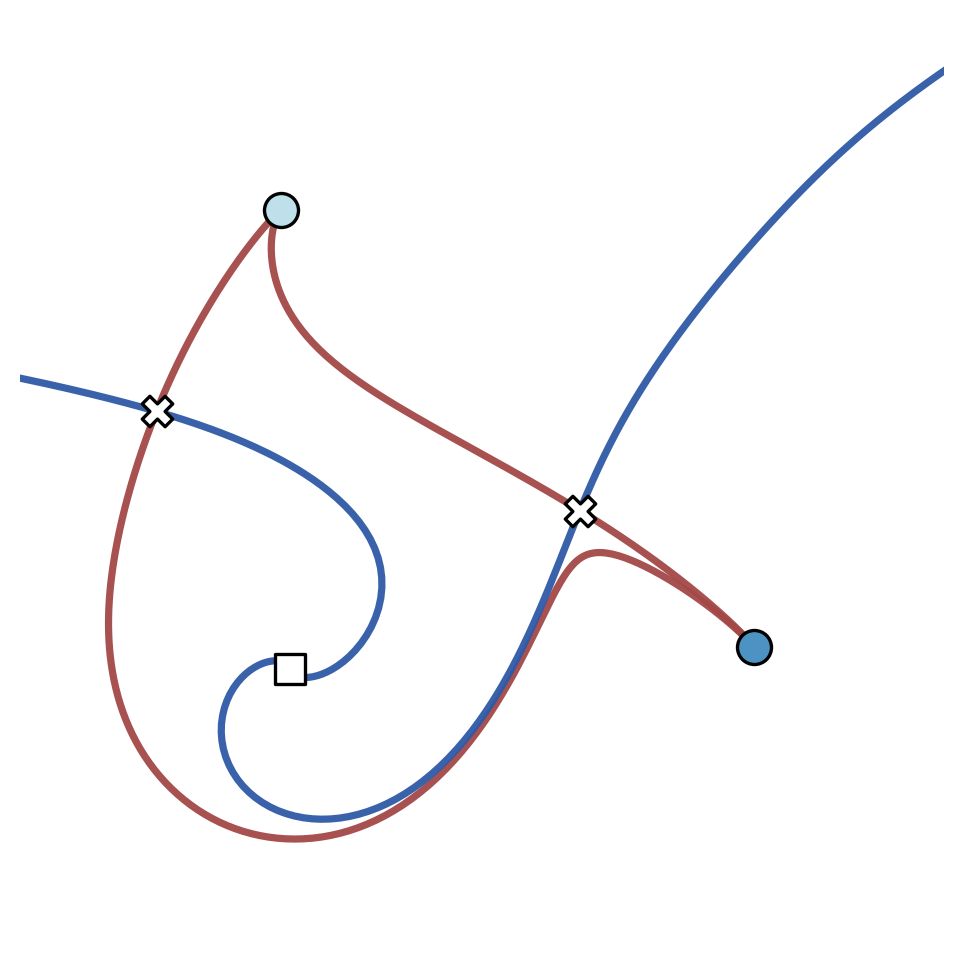

In [65]:

fig = vis.visualize_landscape_t(land, xx, yy, t=-2.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
res= add_phase_plots(land, xx, yy, t=-2.5)
fig = vis.visualize_landscape_t(land, xx, yy, t=-0.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
res = add_phase_plots(land, xx, yy, t=-0.5)
# fig = vis.visualize_potential(land, xx, yy, 0, zlim = (-80, 20), rot_contour=True)
plt.show()

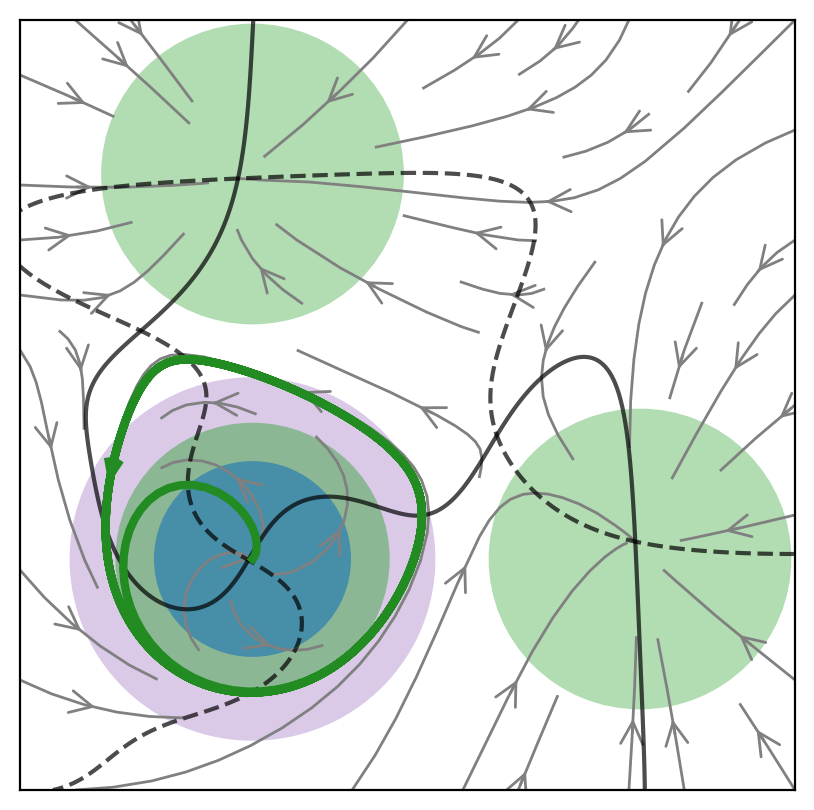

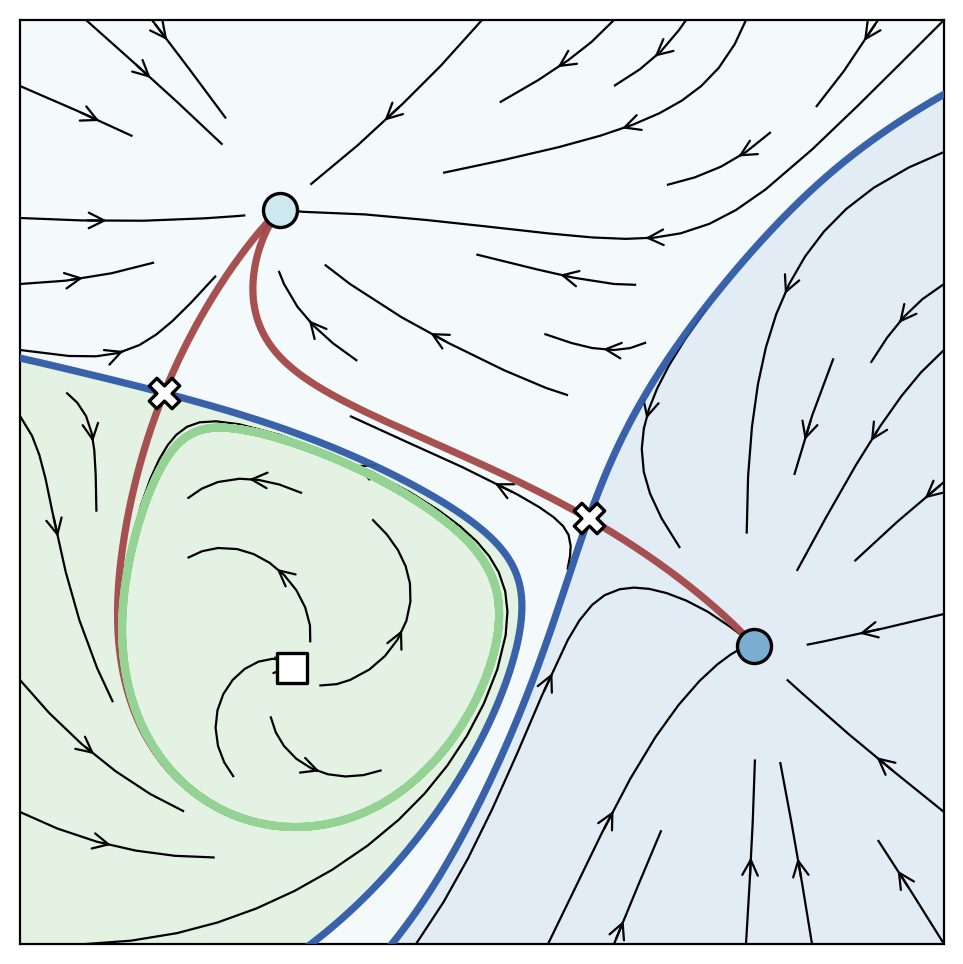

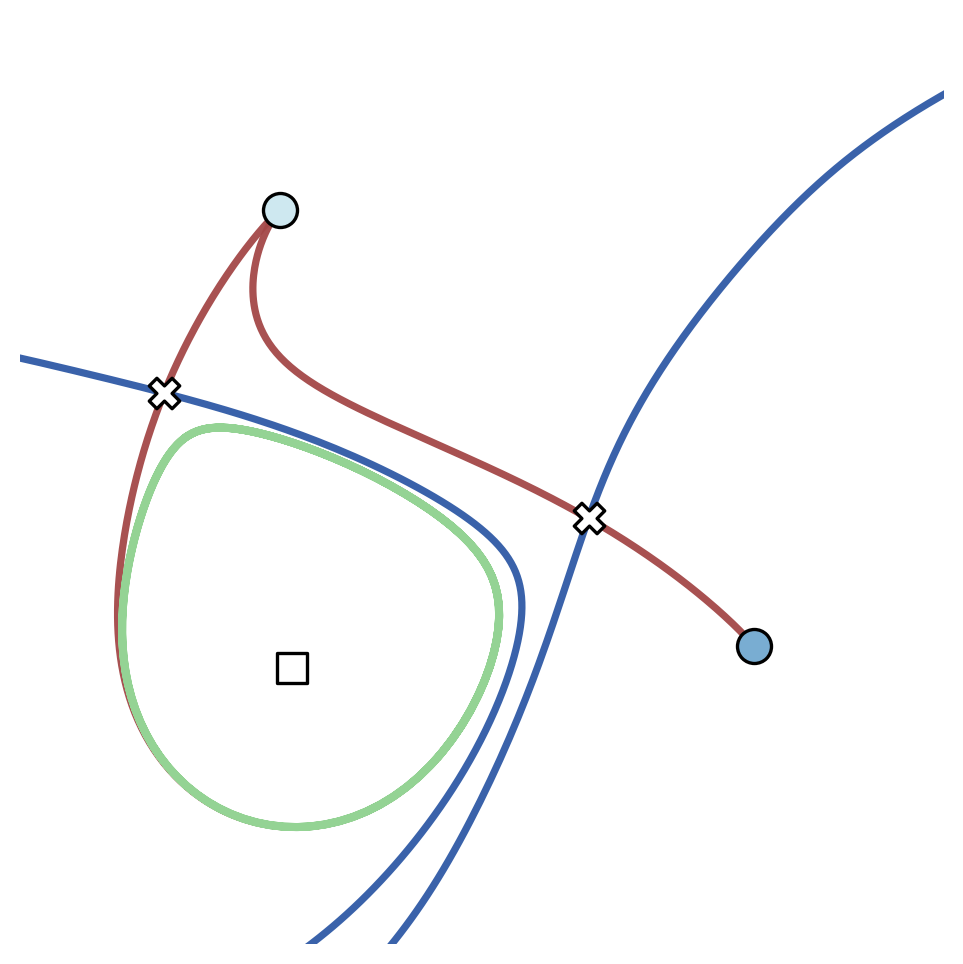

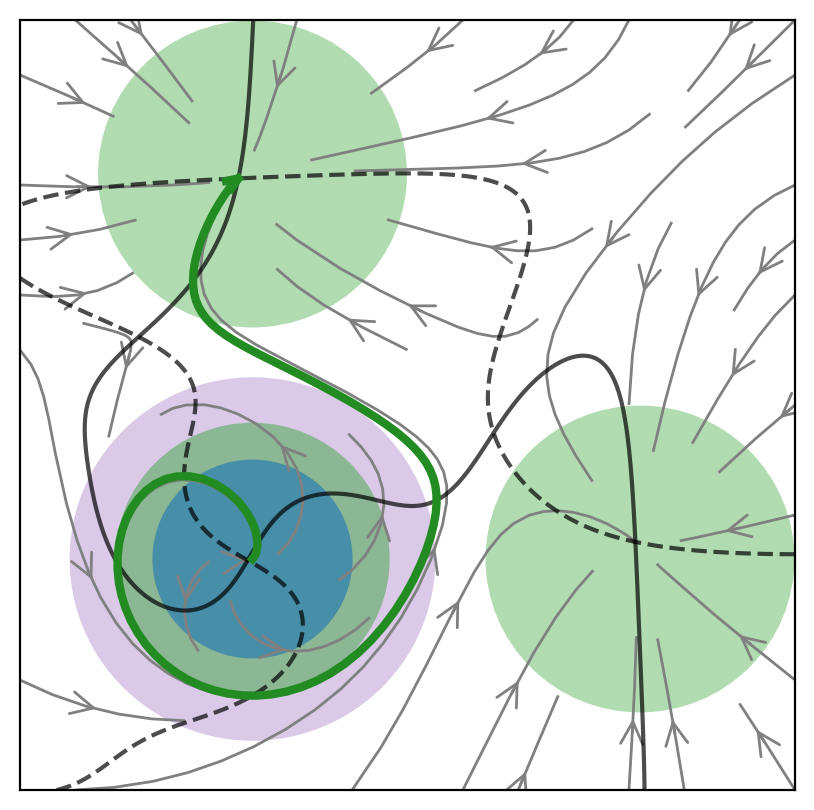

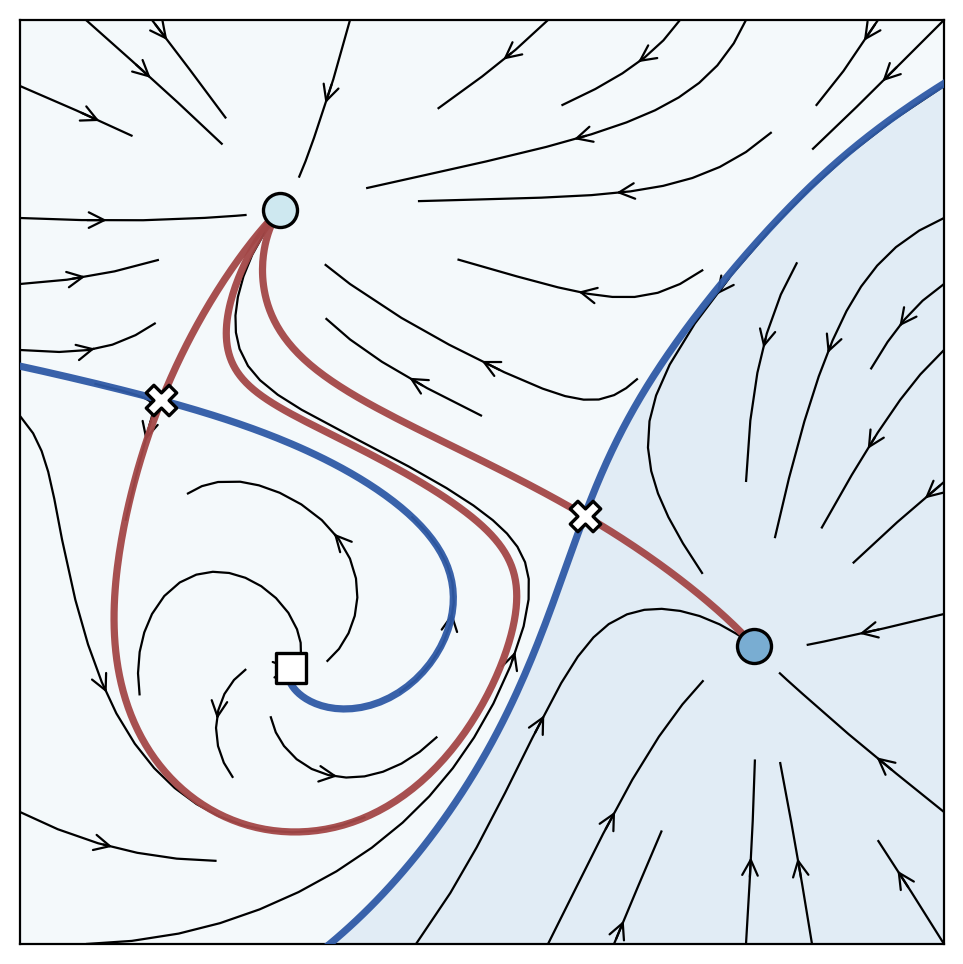

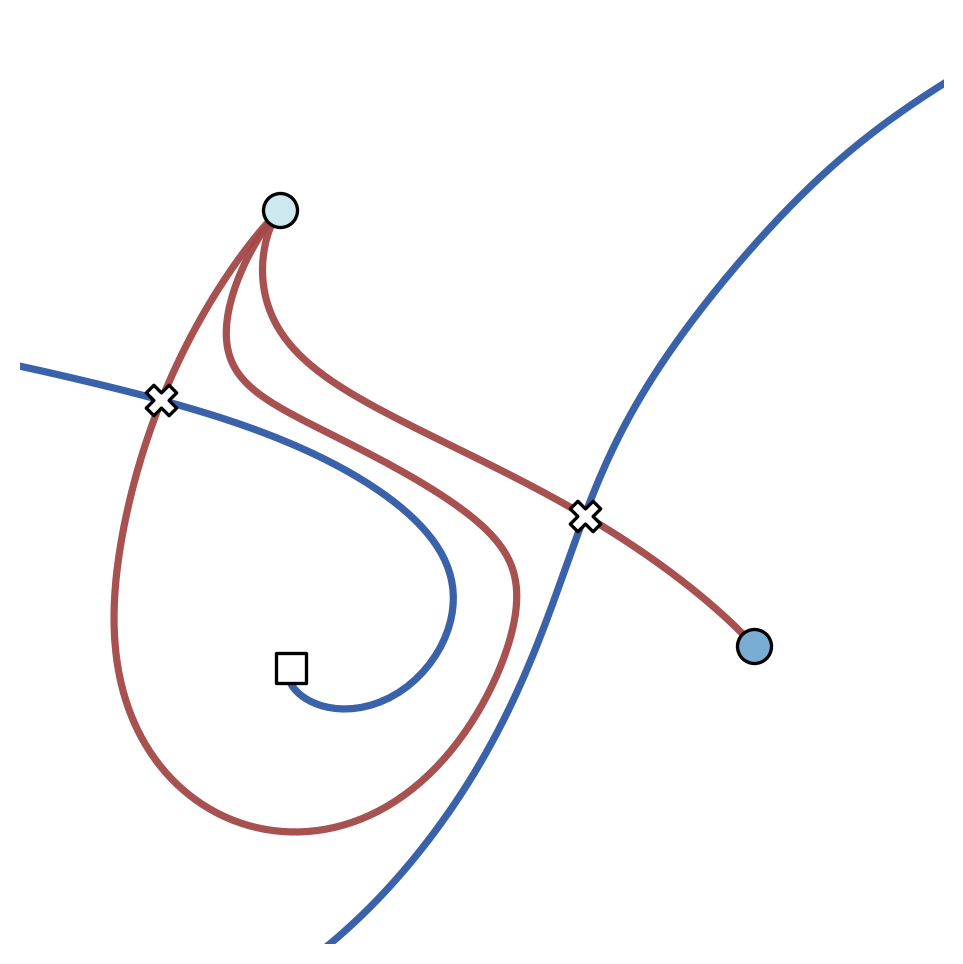

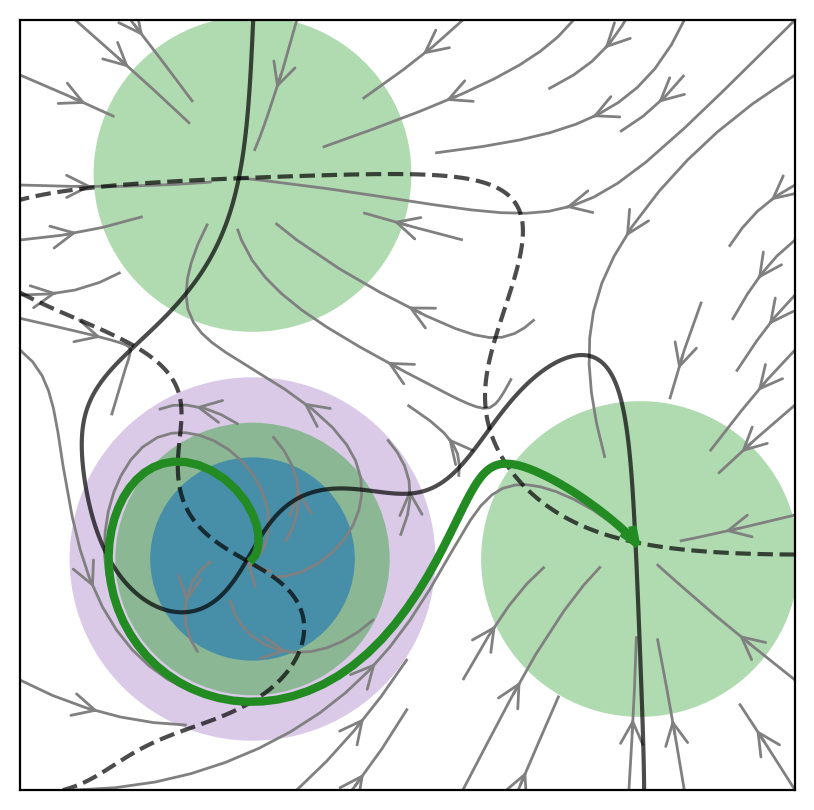

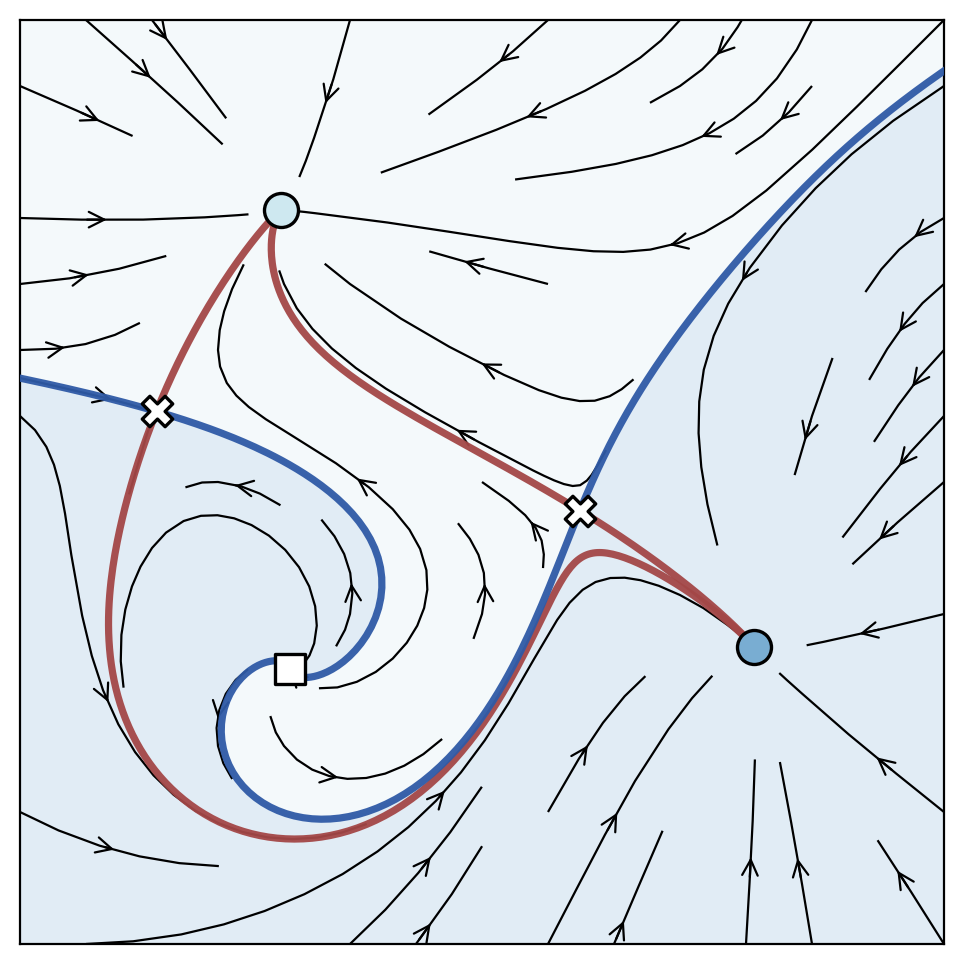

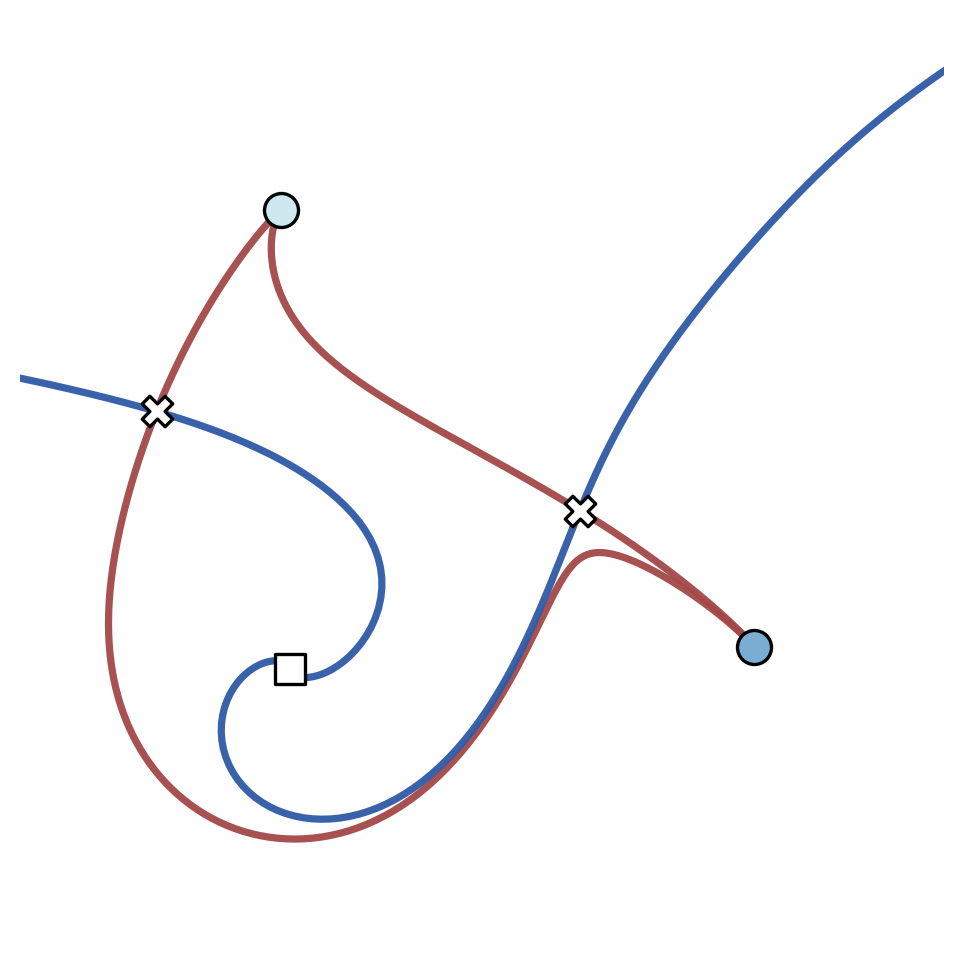

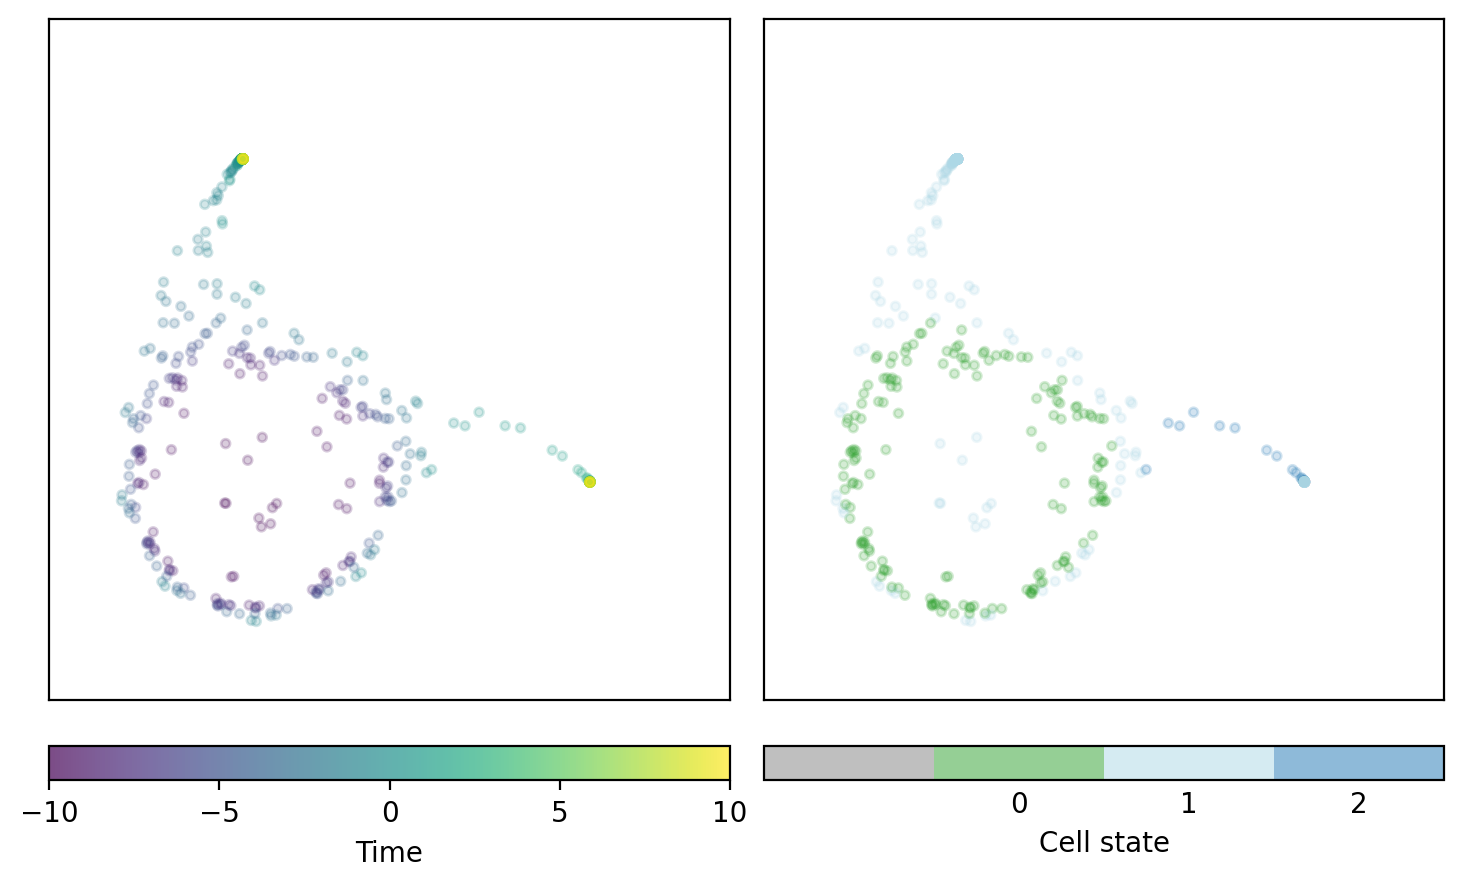

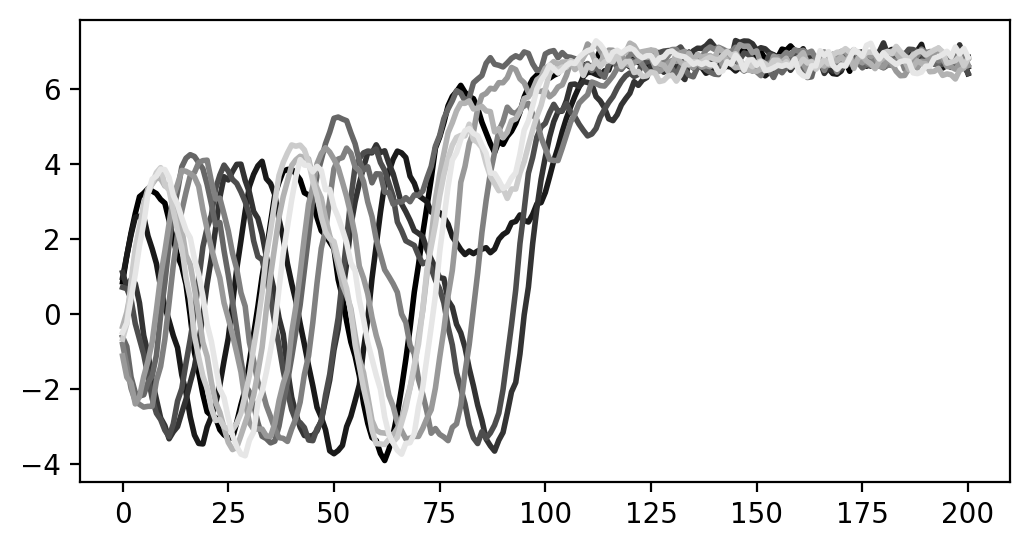

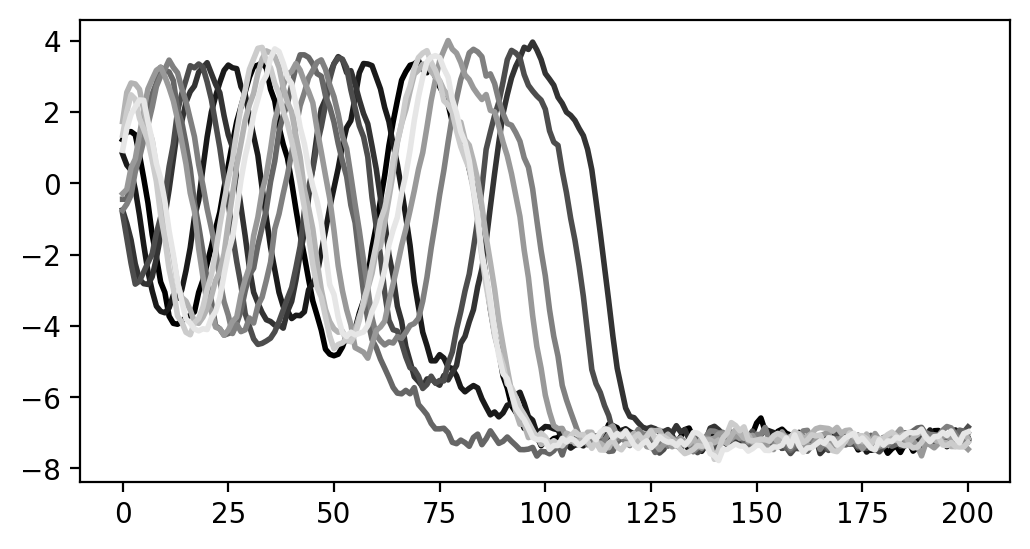

In [5]:

theta = np.linspace(0*np.pi, 2*np.pi, 10, endpoint=False)
land.init_cells(10, (1*np.cos(theta), 1*np.sin(theta)), 0.5)
# land.init_cells(10, (0., 0.), 0.5)
fig = vis.get_and_plot_traj(land, -10., 10, 51, L, noise=0., s=10, frozen=False, state_measure='basin', state_colors=order_colors, t_ticks=5)
ax = fig.axes
ax[0].set_ylim((-6, 14))
ax[0].set_xlim((-6, 14))

ax[1].set_ylim((-6, 14))
ax[1].set_xlim((-6, 14))
plt.show()

theta = np.linspace(0*np.pi, 2*np.pi, 10, endpoint=False)
land.init_cells(10, (1*np.cos(theta), 1*np.sin(theta)), 0.5)
traj, states = land.run_cells(-10, 10, 201, 0.5, 50, get_states='gaussian')

plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:]+traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
# ax = plt.gca()
# ax.set_aspect('equal')
plt.show()



plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:] - traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
plt.show()

# vis.plot_cells(land, 20)
# plt.show()

In [8]:
print(land.result)

None


# Homoclinic with middle saddle

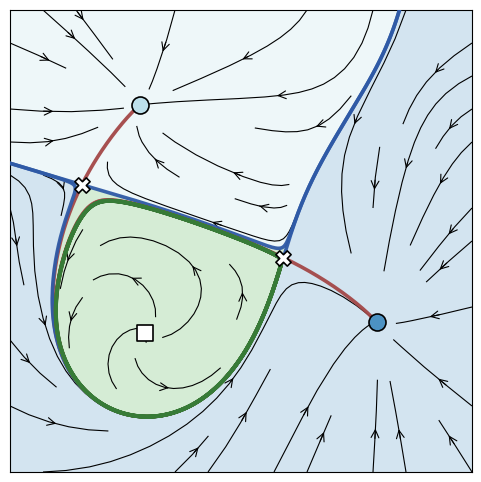

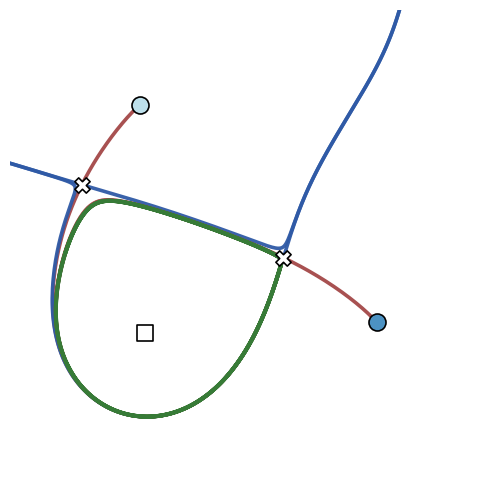

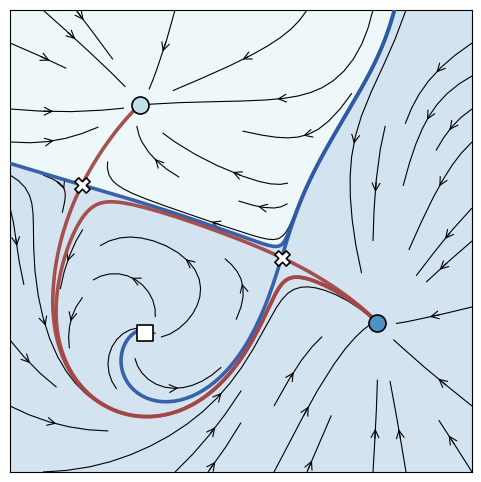

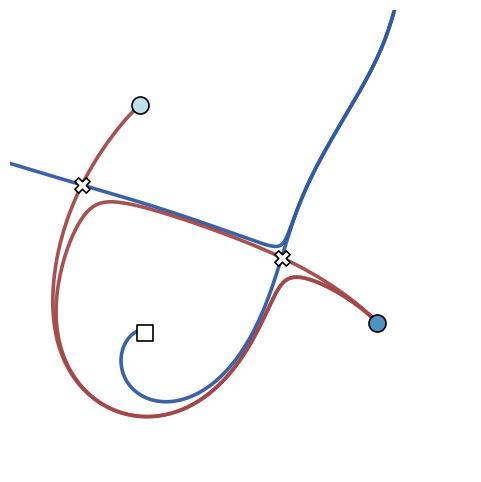

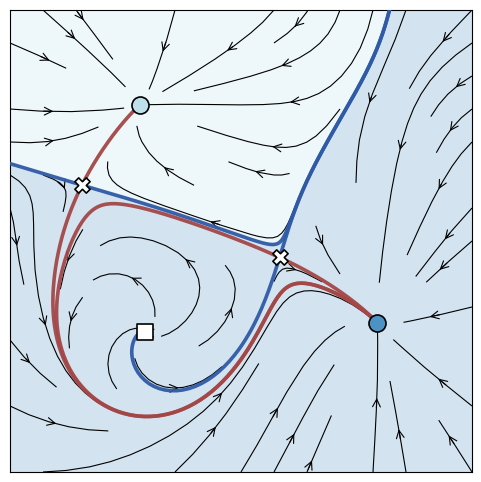

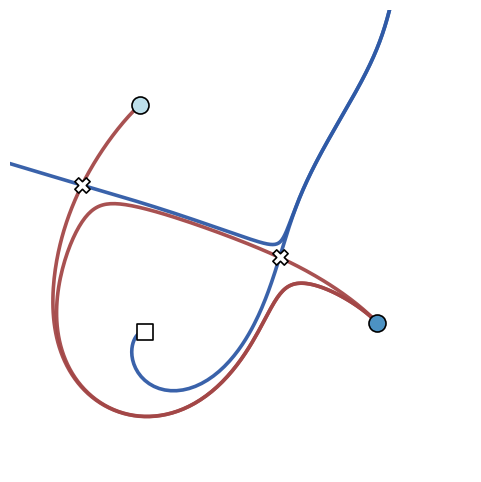

In [93]:
L = 10.
npoints = 401
q = np.linspace(-L*0.6, L*1.4, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

M1 = Node(x=0., y=0., a=5., s=3.)
M2 = Node(x=0., y=10., a=(3,4), s=(3,3), tau=5) # 3, 4 for s  (s = 3,5 gives good symmetry)
M3 = Node(x=10., y=0., a=(3,4), s=(3,7), tau=5)
# M4 = Node(x=8, y=8, a=0.5, s=5)
M4 = Node(x=5, y=6, a=0.5, s=3)

C1 = Center(x=0, y=0, a=3, s=4) # a=3, s=4
R1 = UnstableNode(x=0, y=0, a=(10, 10), s=(2.2, 2.2), tau=5)

land = Somitogenesis_Landscape([C1, M1, M2, M3, R1], regime=mr.mr_sigmoid, n_regimes=2, A0 = 0.001, x0 = (5, 5))

res, grid = add_phase_plots(land, xx, yy, t=-8.48)

res, grid = add_phase_plots(land, xx, yy, t=-8.)
res, grid = add_phase_plots(land, xx, yy, t=-7.5)


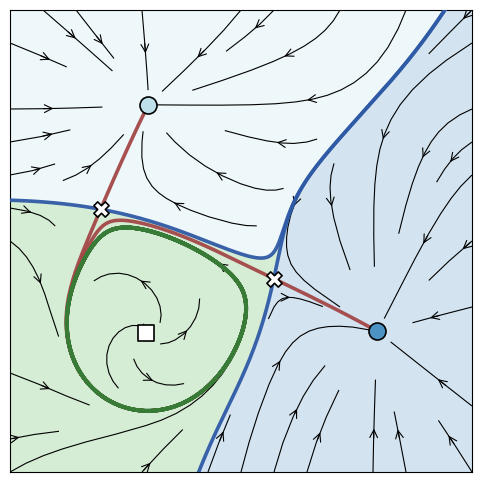

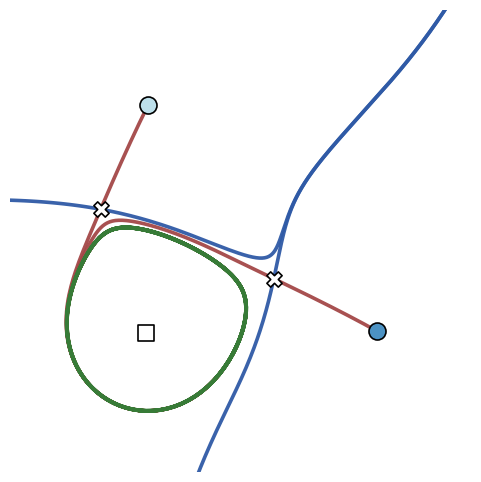

In [58]:
L = 10.
npoints = 401
q = np.linspace(-L*0.6, L*1.4, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

M1 = Node(x=0., y=0., a=5., s=3)
M2 = Node(x=0., y=10., a=(3,4), s=(3,5), tau=5) # 3, 4 for s  (s = 3,5 gives good symmetry)
M3 = Node(x=10., y=0., a=(3,4), s=(3,6), tau=5)
# M4 = Node(x=8, y=8, a=0.5, s=5)
M4 = Node(x=5, y=6, a=0.5, s=3)

C1 = Center(x=0, y=0, a=4, s=3) # a=3, s=4
R1 = UnstableNode(x=0, y=0, a=(10, 10), s=(2., 3.), tau=5)

land = Somitogenesis_Landscape([C1, M1, M2, M3, R1], regime=mr.mr_sigmoid, n_regimes=2, A0 = 0.001, x0 = (5, 5))

res, grid = add_phase_plots(land, xx, yy, t=-10.)

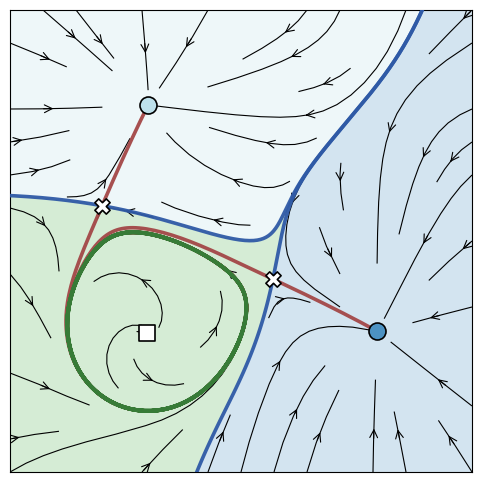

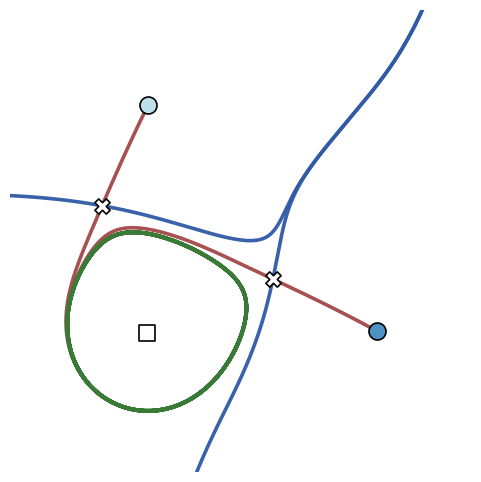

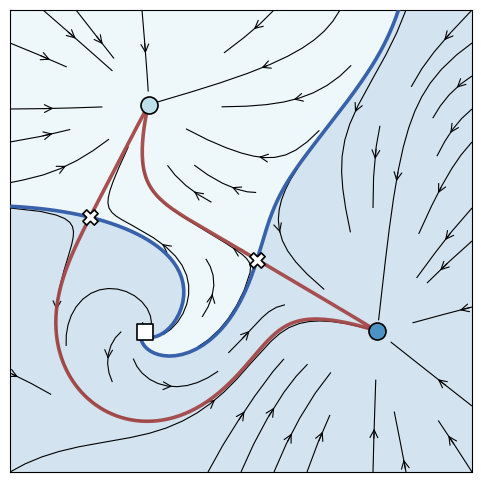

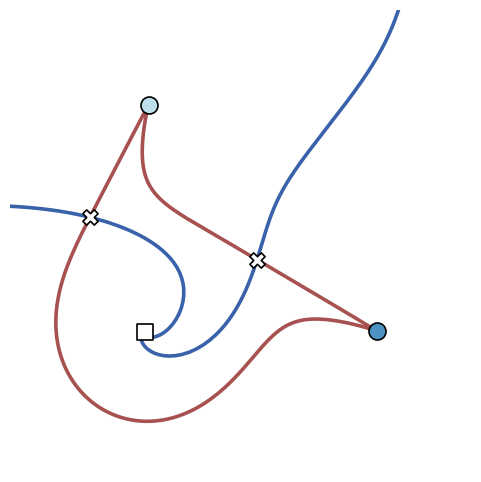

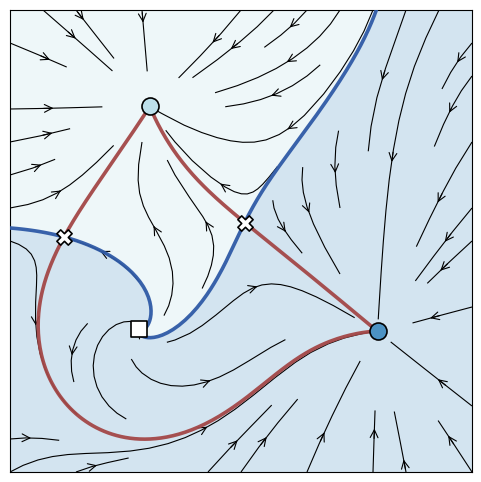

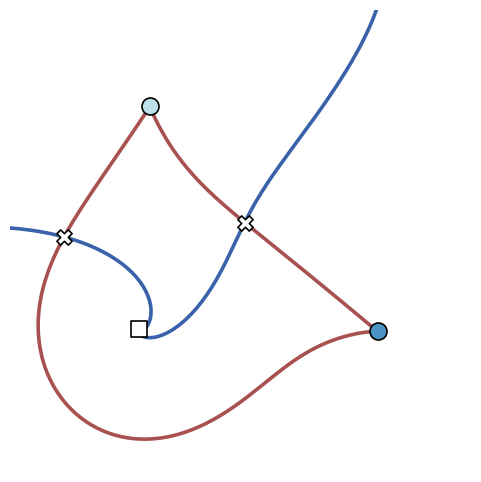

In [55]:

res1, grid1 = add_phase_plots(land, xx, yy, t=-5.)
res2, grid2 = add_phase_plots(land, xx, yy, t=0.)


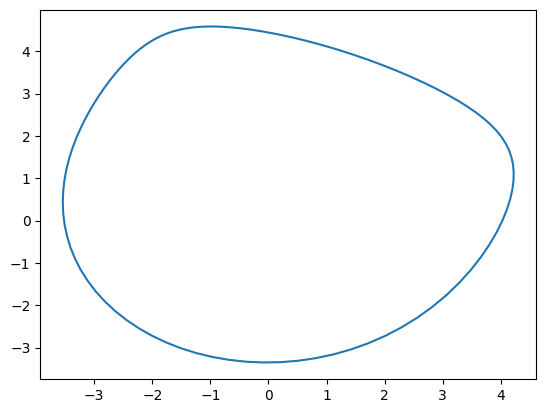

In [42]:
period_steps = res['attractors'][2]['period_steps']

cycle = res['attractors'][2]['trajectory'][:period_steps+1]

plt.plot(cycle[:,0], cycle[:,1])

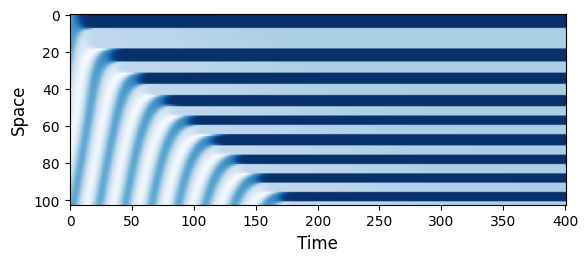

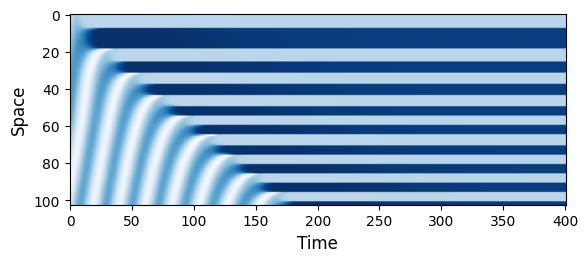

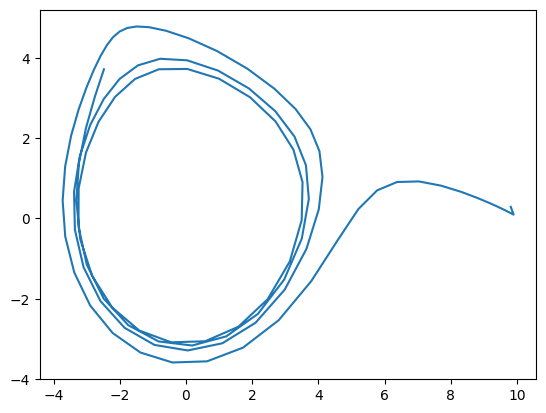

In [43]:
time_pars = (-5., 50., 401)
morphogen_times = (0.,)

fitness_pars = {
    'ncells': len(cycle),
    'time_pars': time_pars,
    'init_state': cycle.T,
    't0_shift': 0.25,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.0,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.,
    't_stable': 1, # how many timepoints should be at steady state
    'ndt': 50,
    # 'n_boundaries': 10,
}
land.get_fitness(fitness_pars)

plt.imshow(land.result[0], cmap='Blues', aspect=1.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.imshow(land.result[1], cmap='Blues', aspect=1.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.plot(land.result[0][55, :], land.result[1][55, :])

In [44]:
grid

{'basin_labels': array([[2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        [2, 2, 2, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]]),
 'unresolved_mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 'x_coords': array([-6.  , -5.95, -5.9 , -5.85, -5.8 , -5.75, -5.7 , -5.65, -5.6 ,
        -5.55, -5.5 , -5.45, -5.4 , -5.35, -5.3 , -5.25, -5.2 , -5.15,
        -5.1 , -5.05, -5.  , -4.95, -4.9 , -4.85, -4.8 , -4.75, -4.7 ,
        -4.65, -4.6 , -4.55, -4.5 , -4.45, -4.4 , -4.35, -4.3 , -4.25,
        -4.2 , -4.15, -4.1 , -4.05, -4.  , -3.95, -3.9 , -3.85, -3.8 ,
        -3.75, -3.7 , -3.65,

In [45]:
states = land.get_cell_states(0., coordinate=(land.result[0].flatten(), land.result[1].flatten()), measure='basin static', basin_grid=grid)
states=np.reshape(states, land.result[0].shape)

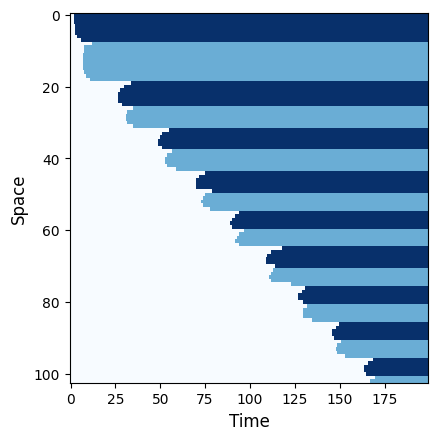

In [46]:

plt.imshow(states[:, :200], cmap='Blues', aspect=2, interpolation='none')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

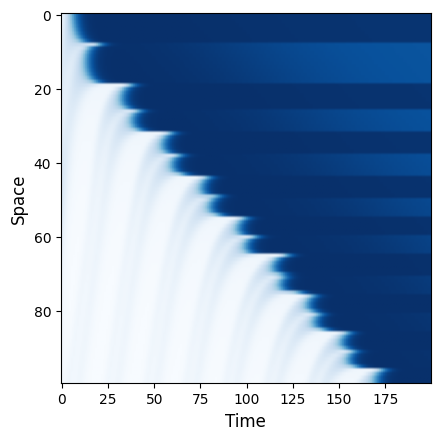

In [47]:
kymo = land.result[0]**2 + land.result[1]**2

plt.imshow(kymo[:100, :200], cmap='Blues', aspect=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

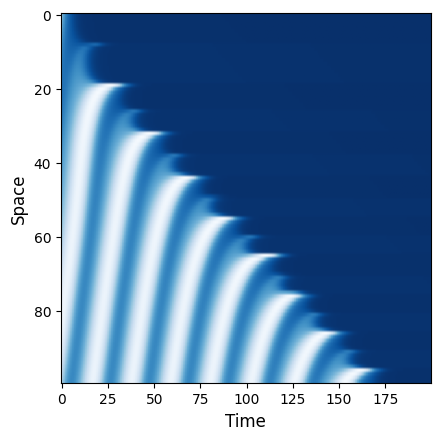

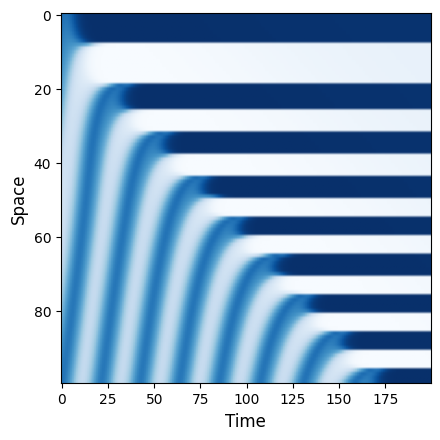

In [48]:
kymo = (land.result[0] + land.result[1])/np.sqrt(2)

plt.imshow(kymo[:100, :200], cmap='Blues', aspect=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

kymo = (land.result[0] - land.result[1])/np.sqrt(2)

plt.imshow(kymo[:100, :200], cmap='Blues', aspect=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()


## Phase space plots

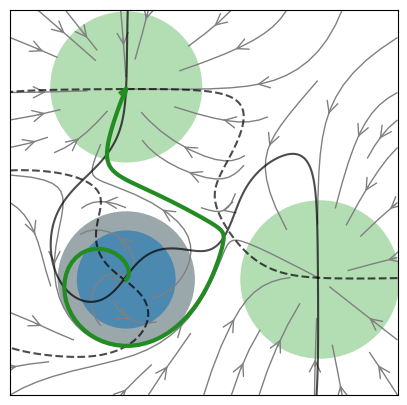

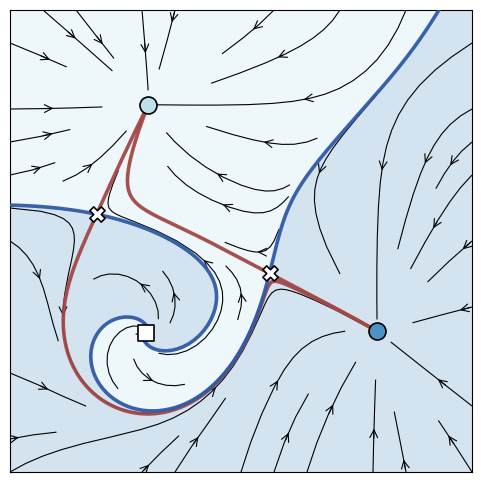

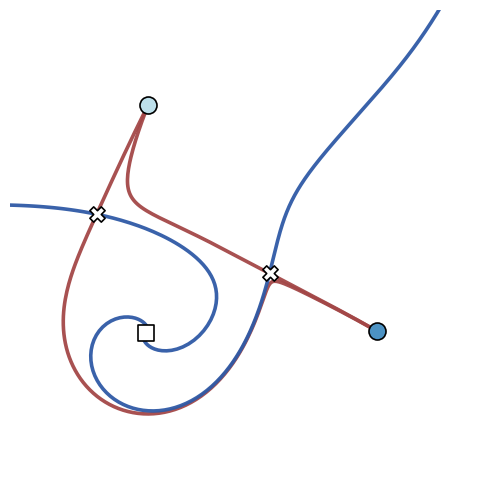

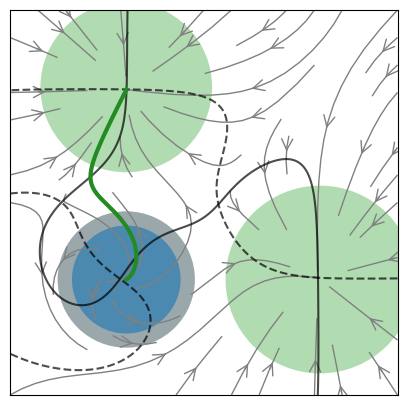

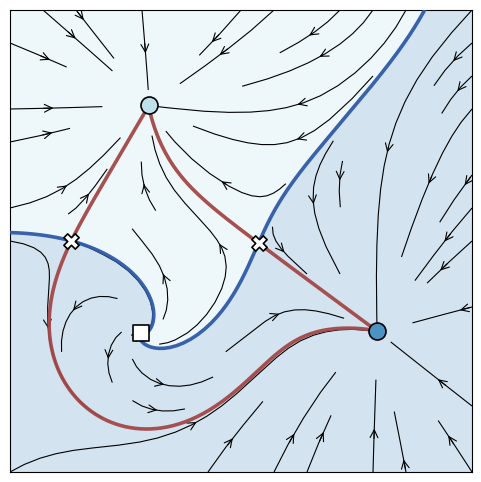

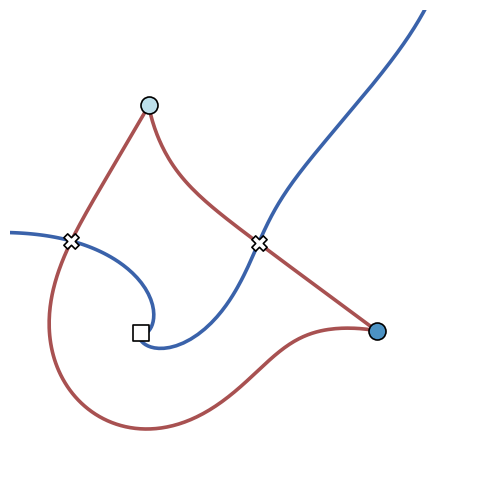

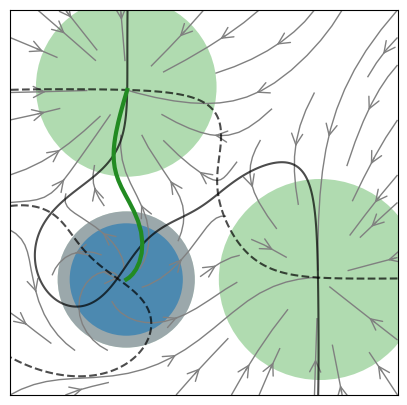

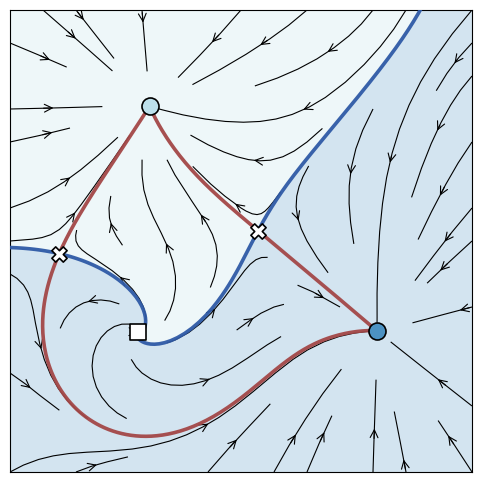

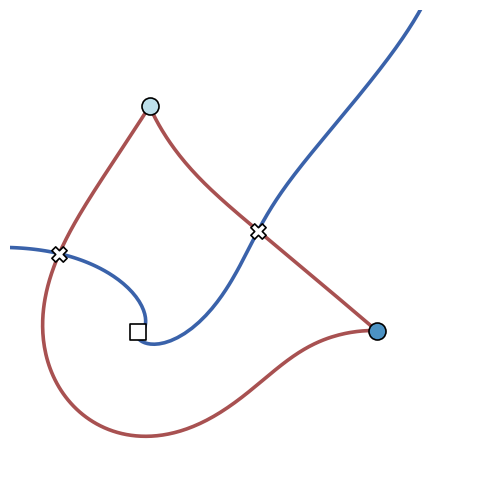

In [54]:

# _____________________________________________________
fig = vis.visualize_landscape_t(land, xx, yy, t=-8.2, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-8.1)
fig = vis.visualize_landscape_t(land, xx, yy, t=-2.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-2.5)
fig = vis.visualize_landscape_t(land, xx, yy, t=-0.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-0.5)
# fig = vis.visualize_potential(land, xx, yy, 0, zlim = (-80, 20), rot_contour=True)
plt.show()


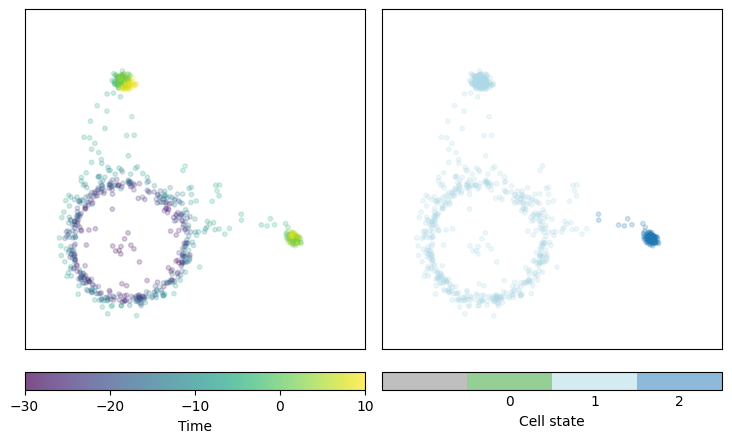

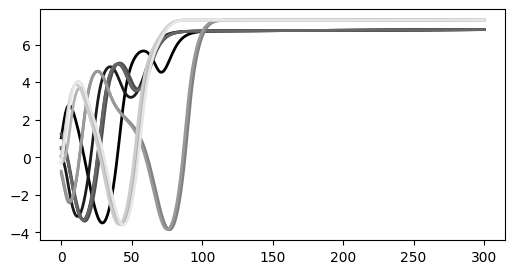

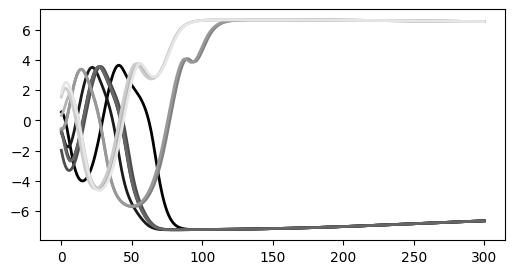

In [69]:

land.init_cells(10, (0., 0.), 0.5)
fig = vis.get_and_plot_traj(land, -30., 10, 81, L, 0.5, s=10, frozen=False, state_measure='basin_static', t_freeze=-20., state_colors=order_colors, t_ticks=5)
ax = fig.axes
ax[0].set_ylim((-6, 14))
ax[0].set_xlim((-6, 14))

ax[1].set_ylim((-6, 14))
ax[1].set_xlim((-6, 14))
plt.show()



theta = np.linspace(0*np.pi, 2*np.pi, 10, endpoint=False)
land.init_cells(10, (1*np.cos(theta), 1*np.sin(theta)), 0.5)
traj, states = land.run_cells(-10, 10, 301, 0., 50, get_states='gaussian')

plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:]+traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
# ax = plt.gca()
# ax.set_aspect('equal')
plt.show()


plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:] - traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
plt.show()

# land.init_cells(10, (0., 0.), 0.5)
# traj, states = land.run_cells(-10, 10, 21, 0.1, 50, get_states='gaussian')
#
# for i in range(10):
#     plt.scatter(traj[0, i,:], traj[1, i, :], c=states[i, :])
# ax = plt.gca()
# ax.set_aspect('equal')
# plt.show()

# vis.plot_cells(land, 20)

# plt.show()

# SNIC

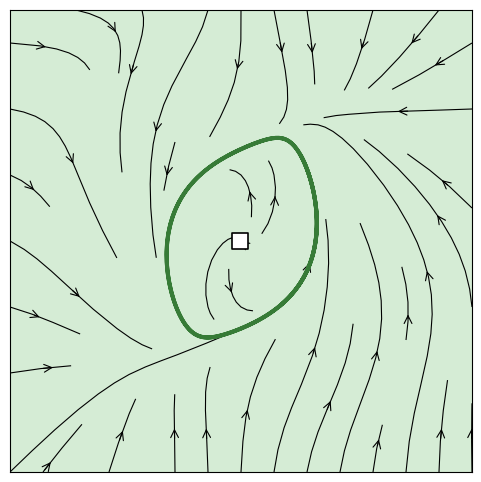

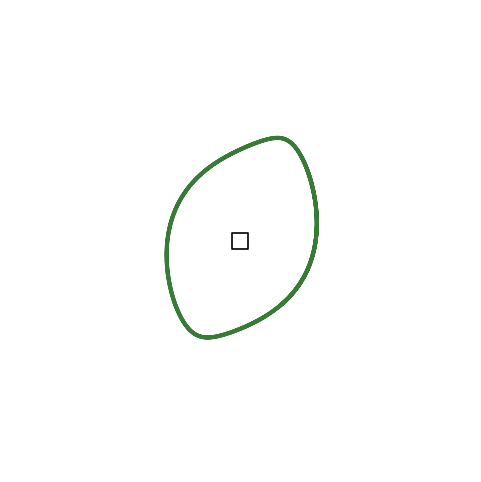

In [49]:
L = 10.
npoints = 401
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q,q, indexing = 'xy')

M1 = Node(x=0., y=0., a=5., s=3)
M2 = Node(x=5., y=5., a=(3,5), s=(3,4), tau=5) # 3, 4 for s
M3 = Node(x=-5., y=-5., a=(3,5), s=(3,4), tau=5)
# M4 = Node(x=8, y=8, a=0.5, s=5)
# M4 = Node(x=5, y=6, a=0.5, s=3)

C1 = Center(x=0, y=0, a=3, s=4)
R1 = UnstableNode(x=0, y=0, a=(10, 10), s=(2., 2.5), tau=5)

land = Somitogenesis_Landscape([C1, M1, M2, M3, R1], regime=mr.mr_sigmoid, n_regimes=2, A0 = 0.001, x0 = (5, 5))

res, grid = add_phase_plots(land, xx, yy, t=-10.)

(-10.0, 10.0)

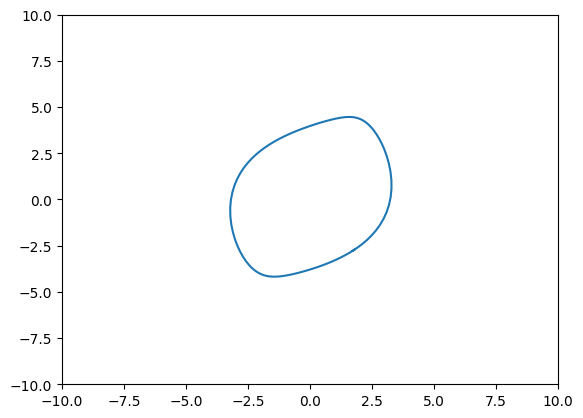

In [50]:
period_steps = res['attractors'][0]['period_steps']

cycle = res['attractors'][0]['trajectory'][:period_steps+1]

plt.plot(cycle[:,0], cycle[:,1])
plt.ylim((-10, 10))
plt.xlim((-10, 10))

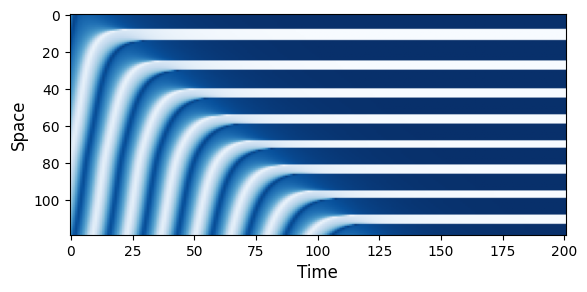

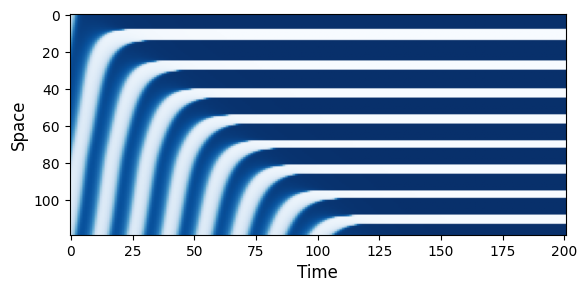

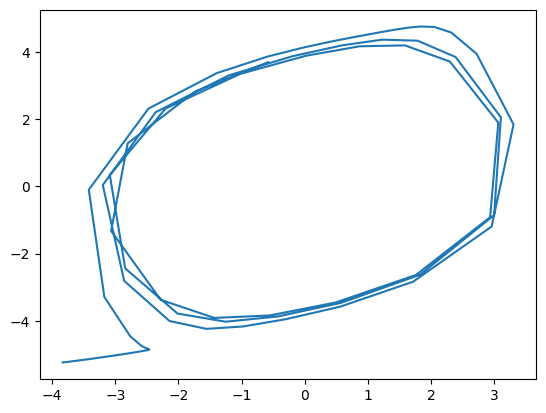

In [51]:
time_pars = (-5., 50., 201)
morphogen_times = (0.,)

fitness_pars = {
    'ncells': len(cycle),
    'time_pars': time_pars,
    'init_state': cycle.T,
    't0_shift': 0.25,  # shift (delay) of the time of transition between 2 neighbor cells
    'noise': 0.0,
    'low_value': -1.,
    'high_value': 1.,
    'penalty_weight': 0.,
    't_stable': 1, # how many timepoints should be at steady state
    'ndt': 50,
    # 'n_boundaries': 10,
}
land.get_fitness(fitness_pars)

plt.imshow(land.result[0], cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.imshow(land.result[1], cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

plt.plot(land.result[0][55, :], land.result[1][55, :])

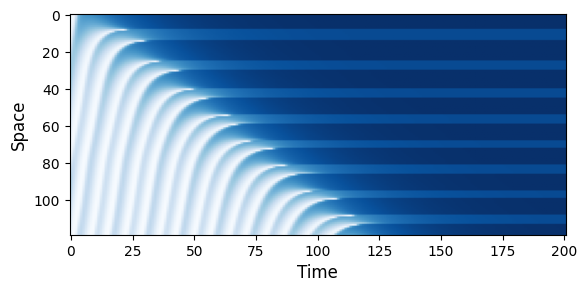

In [106]:
kymo = (land.result[0]**2 + land.result[1]**2)

plt.imshow(kymo, cmap='Blues', aspect=0.75)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

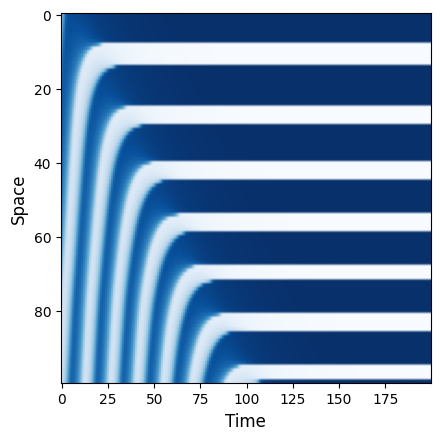

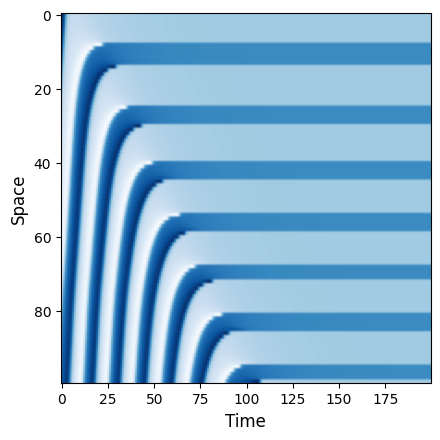

In [107]:
kymo = (land.result[0] + land.result[1])/np.sqrt(2)

plt.imshow(kymo[:100, :200], cmap='Blues', aspect=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()

kymo = (land.result[0] - land.result[1])/np.sqrt(2)

plt.imshow(kymo[:100, :200], cmap='Blues', aspect=2)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Space', fontsize=12)
plt.show()


## Phase space plots

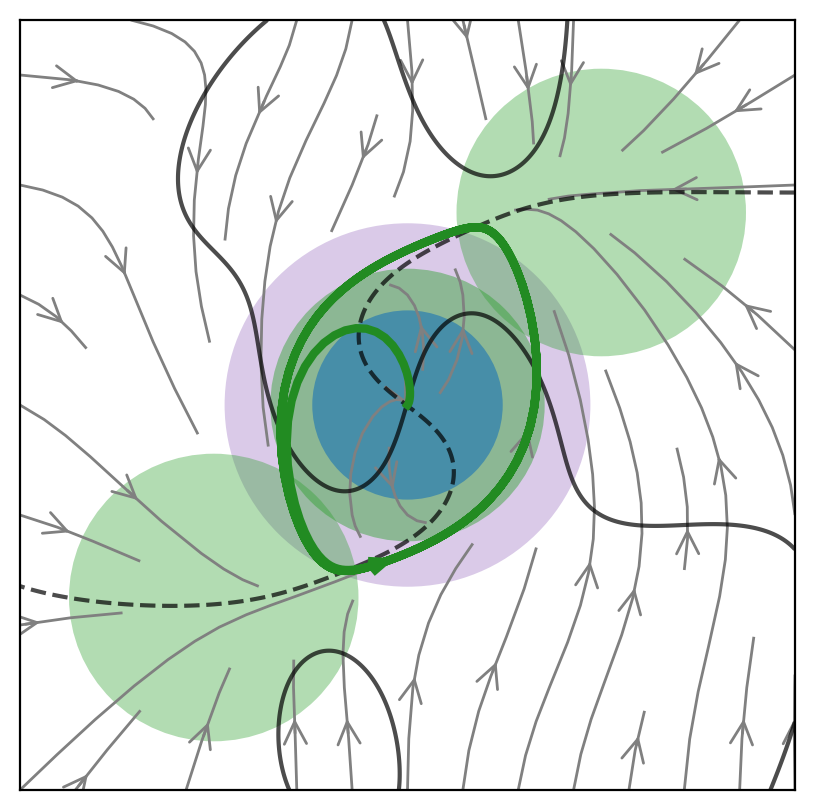

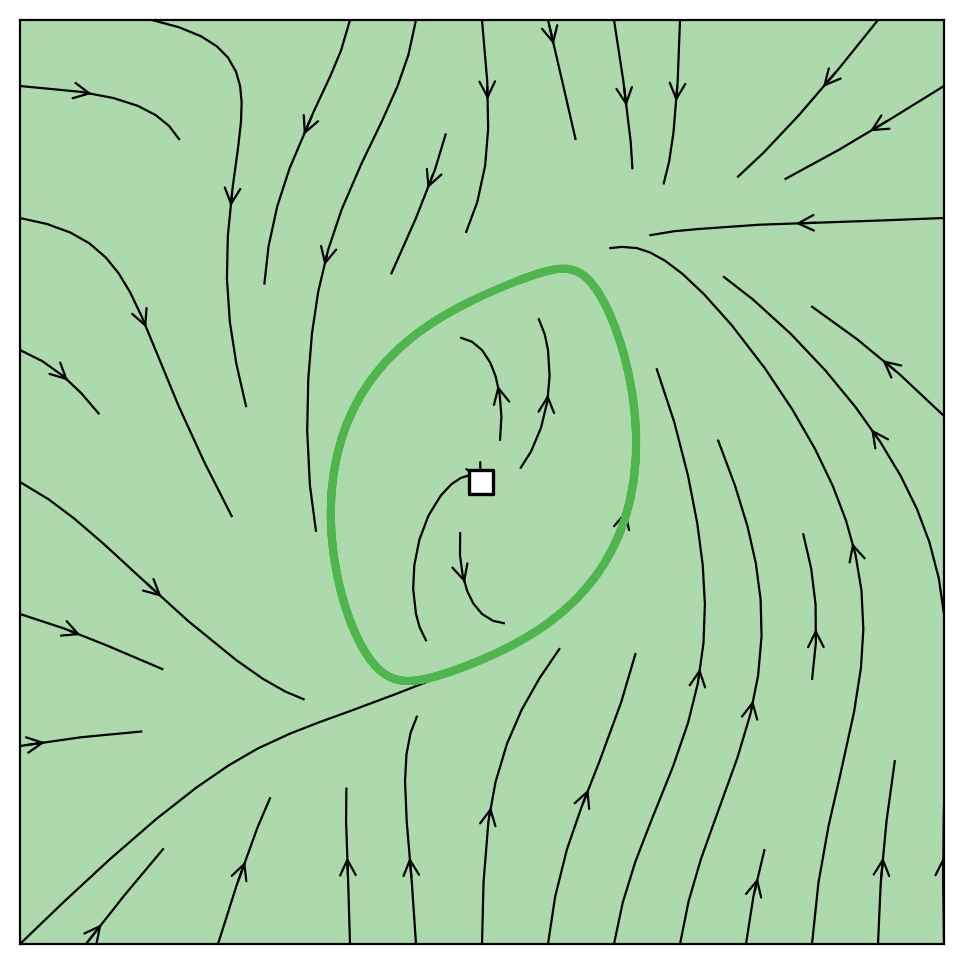

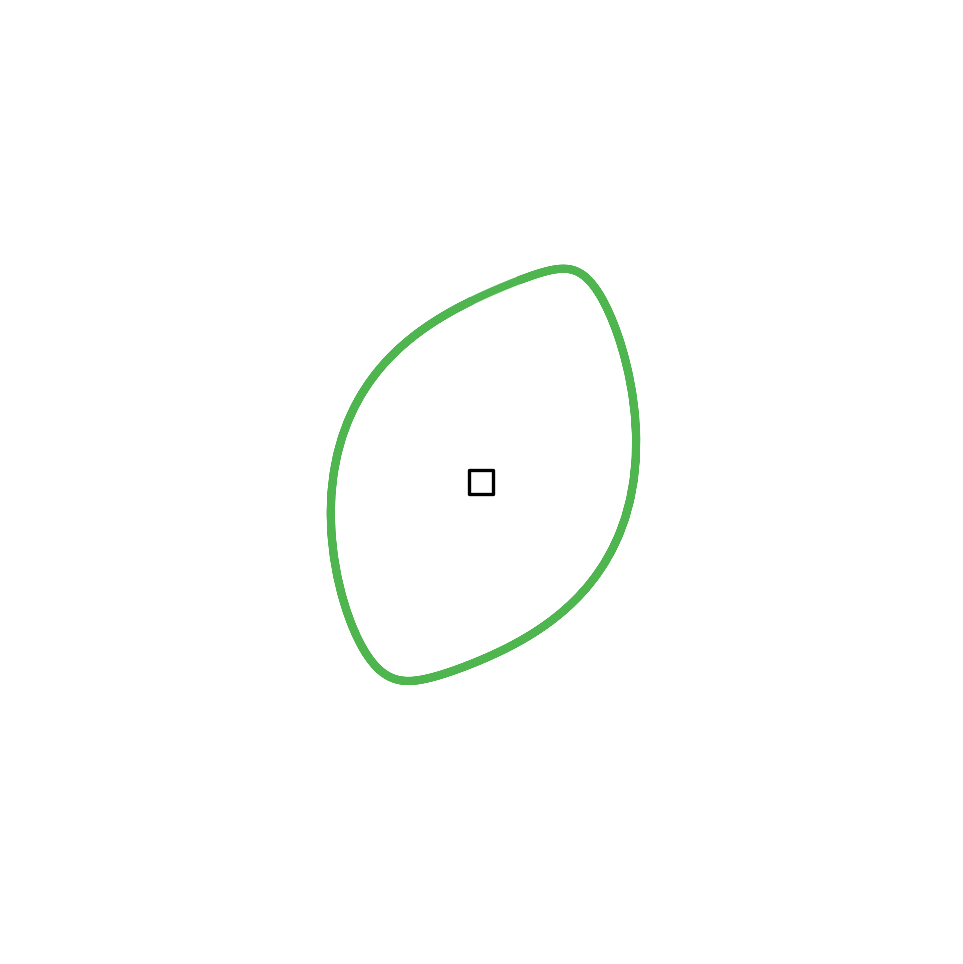

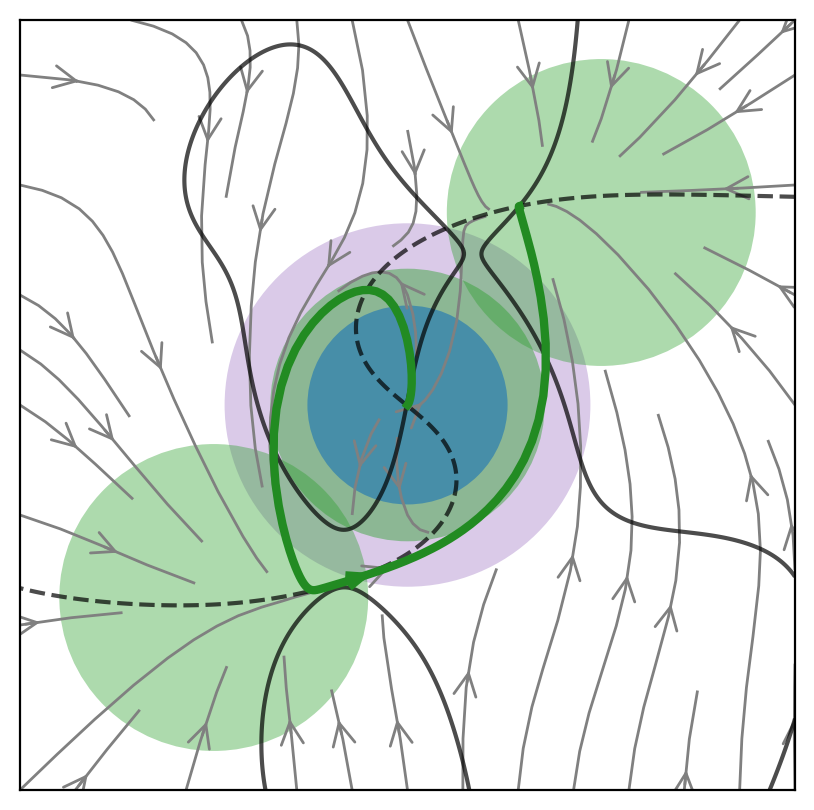

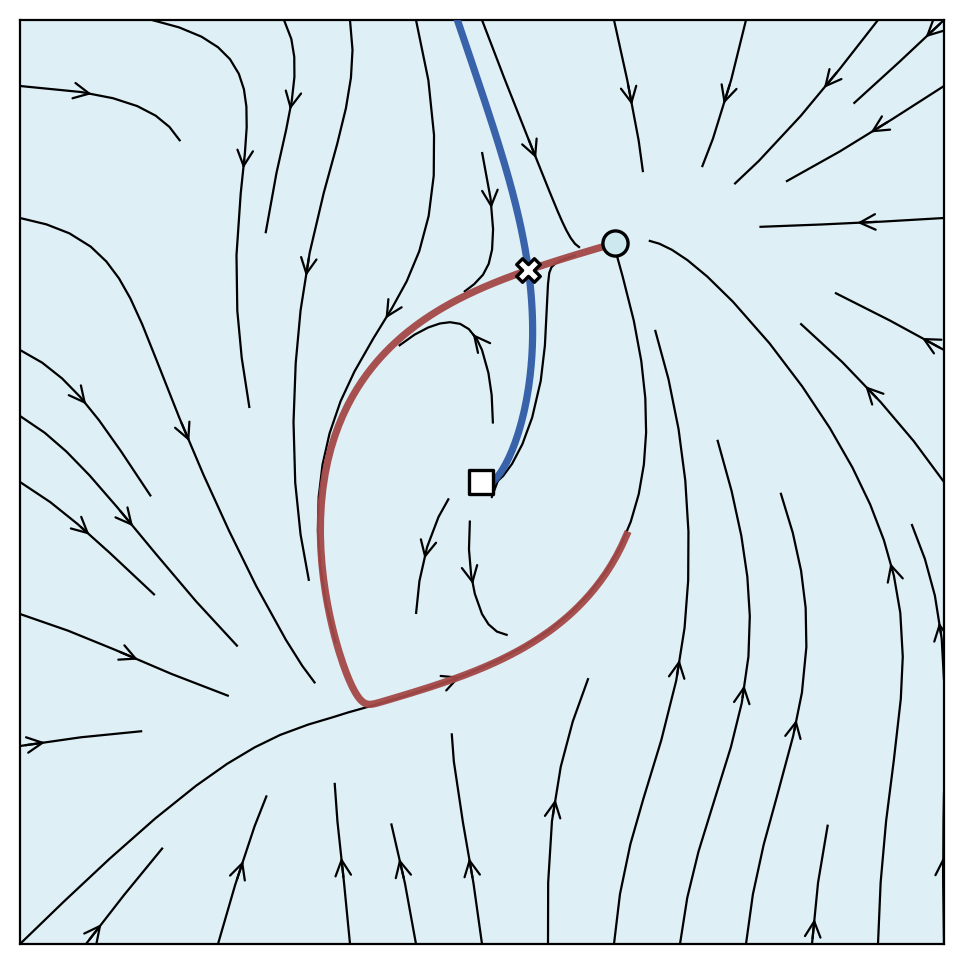

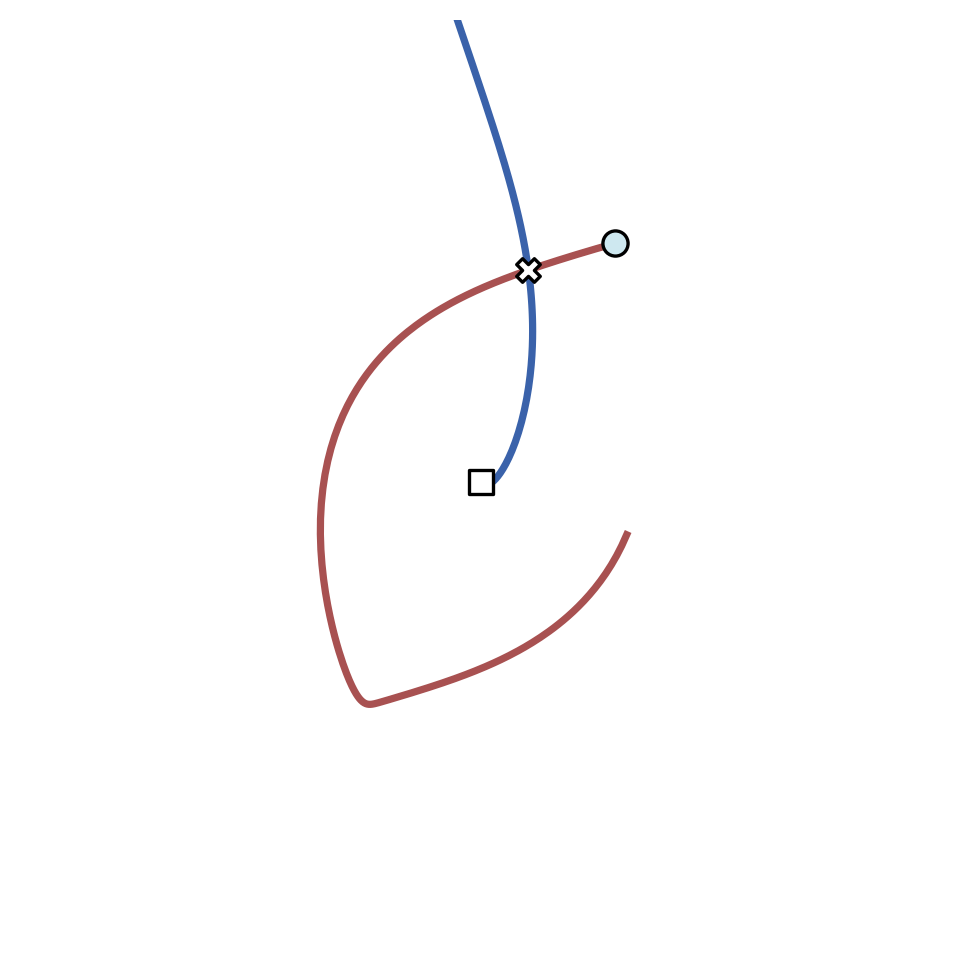

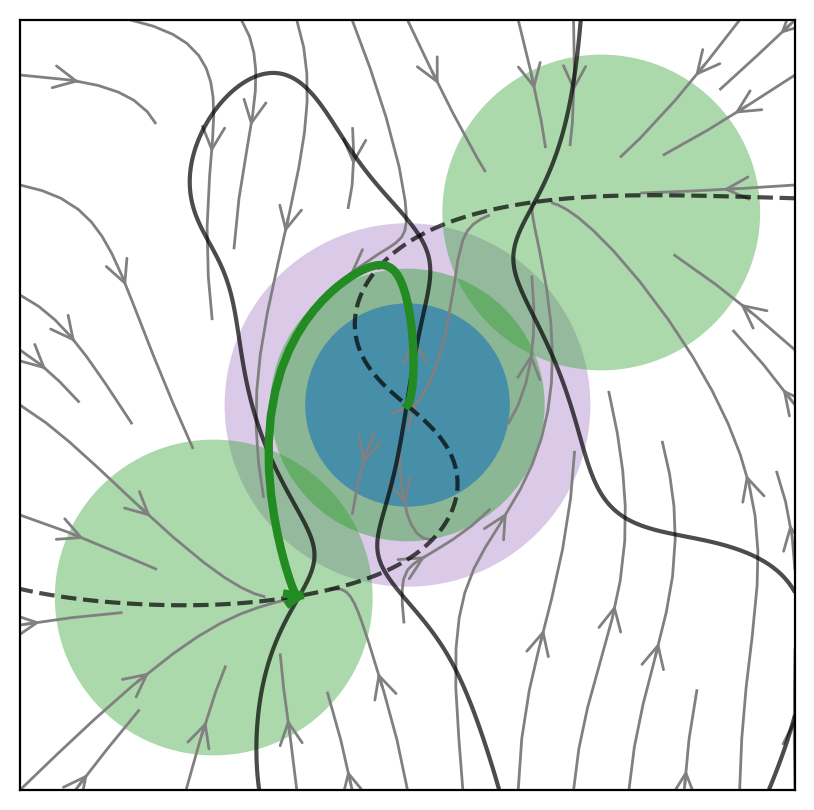

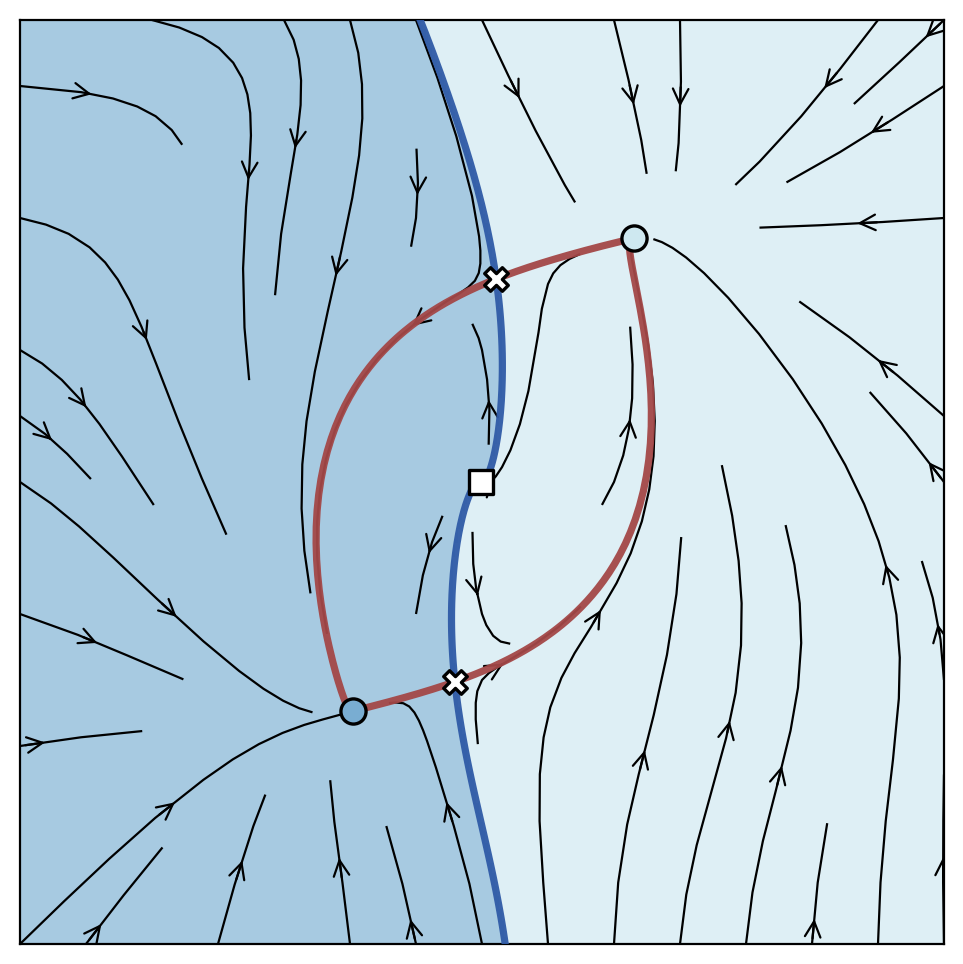

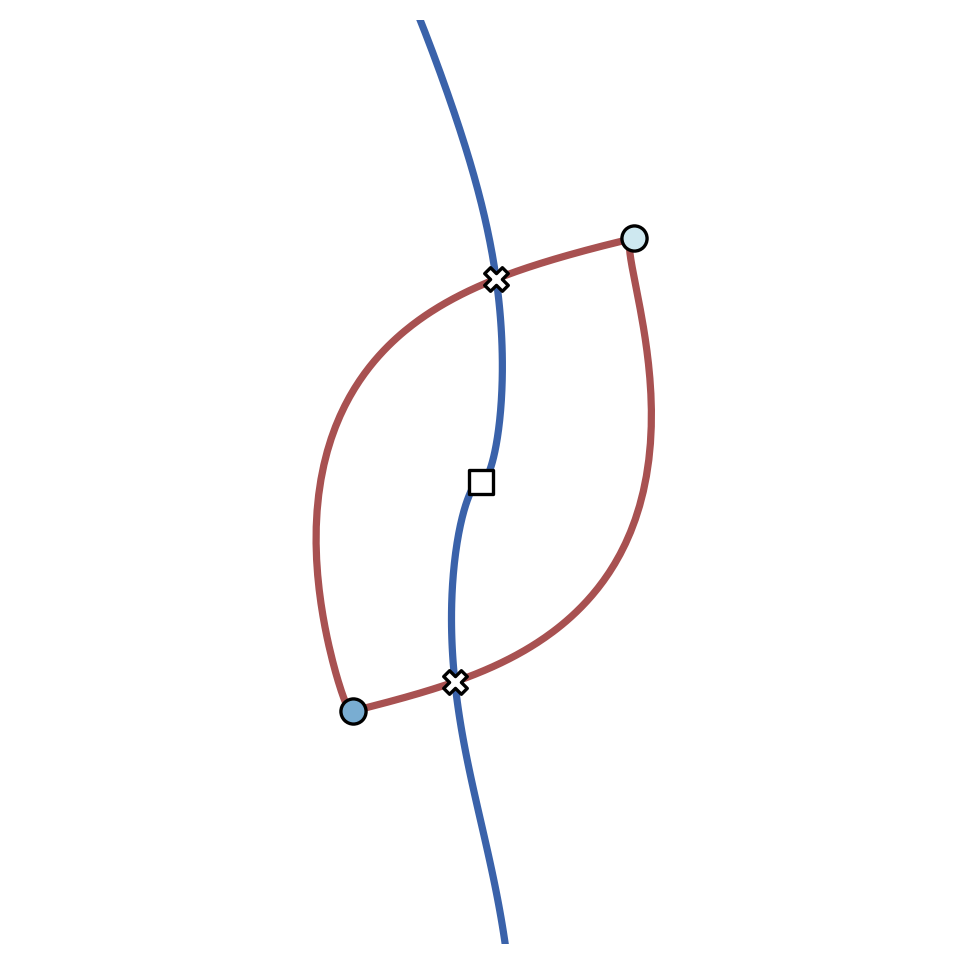

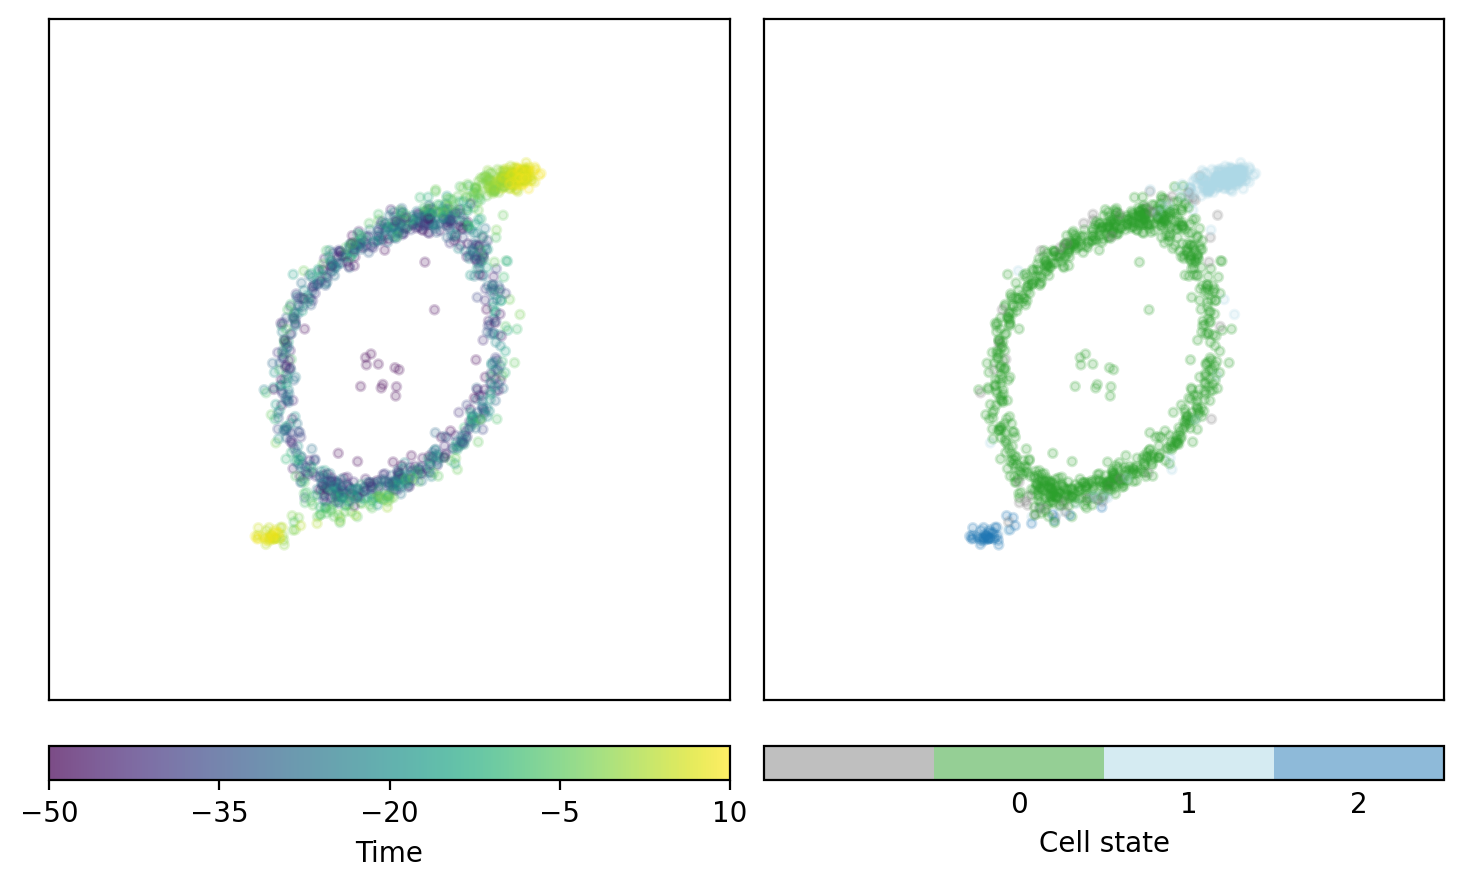

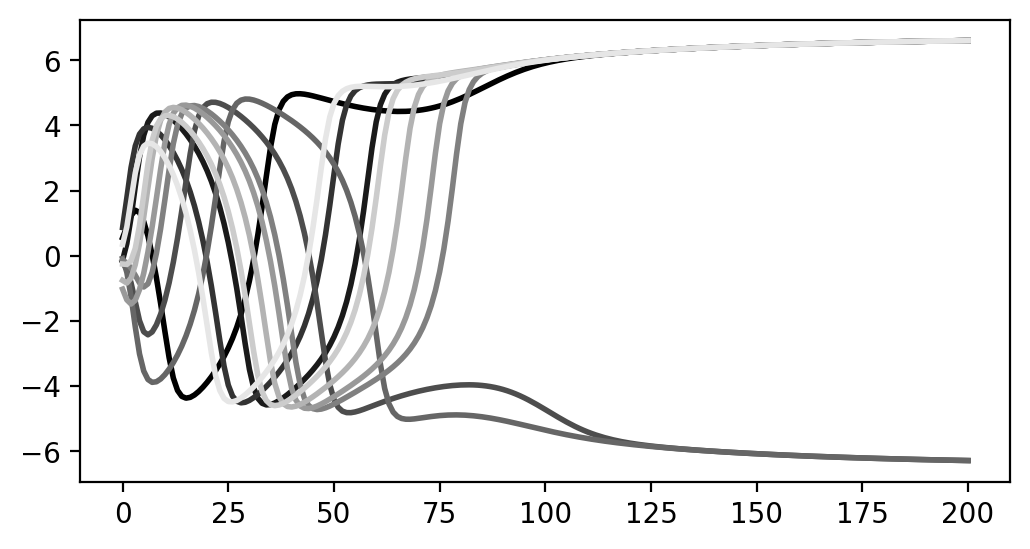

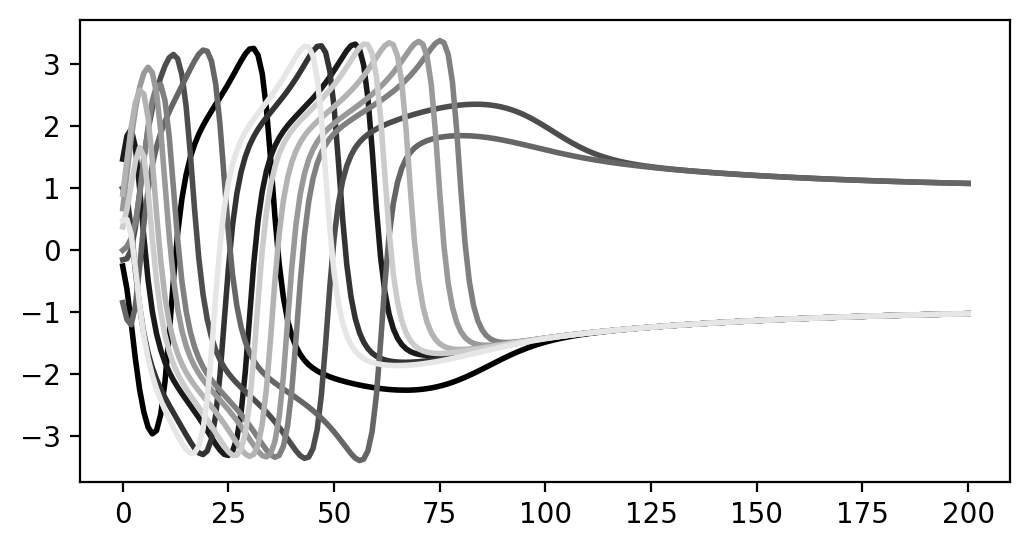

In [5]:

# _____________________________________________________
fig = vis.visualize_landscape_t(land, xx, yy, t=-8.1, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-8.1)
fig = vis.visualize_landscape_t(land, xx, yy, t=-2.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-2.5)
fig = vis.visualize_landscape_t(land, xx, yy, t=-0.5, traj_times=(0, 20, 401), traj_init_cond=(-0., 0.), circle_opacity=0.2)
add_phase_plots(land, xx, yy, t=-0.5)
# fig = vis.visualize_potential(land, xx, yy, 0, zlim = (-80, 20), rot_contour=True)
plt.show()


land.init_cells(10, (0., 0.), 0.5)
fig = vis.get_and_plot_traj(land, -50., 10, 121, L, 0.5, s=10, frozen=False, state_measure='basin', state_colors=order_colors, t_ticks=5)
ax = fig.axes
ax[0].set_ylim((-10, 10))
ax[0].set_xlim((-10, 10))

ax[1].set_ylim((-10, 10))
ax[1].set_xlim((-10, 10))
plt.show()



theta = np.linspace(0*np.pi, 2*np.pi, 10, endpoint=False)
land.init_cells(10, (0.5*np.cos(theta), 0.5*np.sin(theta)), 0.5)
traj, states = land.run_cells(-10, 10, 201, 0., 50, get_states='gaussian')

plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:]+traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
# ax = plt.gca()
# ax.set_aspect('equal')
plt.show()


plt.figure(figsize=(6,3))
for i in range(10):
    plt.plot((traj[0, i,:] - traj[1, i, :])/np.sqrt(2), c=str( theta[i]/2/np.pi), lw=2)
plt.show()


# land.init_cells(10, (0., 0.), 0.5)
# traj, states = land.run_cells(-10, 10, 21, 0.1, 50, get_states='gaussian')
#
# for i in range(10):
#     plt.scatter(traj[0, i,:], traj[1, i, :], c=states[i, :])
# ax = plt.gca()
# ax.set_aspect('equal')
# plt.show()

# vis.plot_cells(land, 20)

# plt.show()